# Load packages

Read in all necessary packages:

In [4]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scanpy as sc
import numpy as np
import decoupler as dc

plt.set_loglevel('WARNING') 

In [2]:
import decoupler as dc

In [3]:
sc.set_figure_params(dpi = 80)
sns.set_style("white")
sns.set_context("talk")
sns.set_style("ticks")

# Load the dataset

## load adata file and define groups for differential expression

In [5]:
adata = sc.read_h5ad('../../tchic_local/fig6_build/legacy/data/20230704_adata_all.h5ad')
adata

AnnData object with n_obs × n_vars = 38117 × 27384
    obs: 'batch', 'day', 'replicates', 'mark', 'day_rep', 'dataset', 'hour', 'celltype', 'celltype_general', 'lineage', 'lin_day', 'percent_mito', 'n_counts', 'n_counts_proteincoding', 'n_genes', 'S_score', 'G2M_score', 'phase', 'enrichment', 'coverage', 'QC', 'pseudotime', 'pseudotime2'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene', 'gene_biotype', 'gene_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'QC_colors', 'batch_colors', 'celltype_colors', 'celltype_general_colors', 'dataset_colors', 'day_colors', 'hour_colors', 'hvg', 'leiden', 'leiden_colors', 'lin_day_colors', 'lineage_colors', 'log1p', 'mark_colors', 'neighbors', 'old_celltype_colors', 'old_leiden_general_colors', 'old_leiden_merge_colors', 'pca', 'phase_colors', 'predicted_final_colors', 'predicted_id_E75_colors', 'predicted_id_E85_colors', 'replicates_colors', 'umap', 'umap_density_mark_par

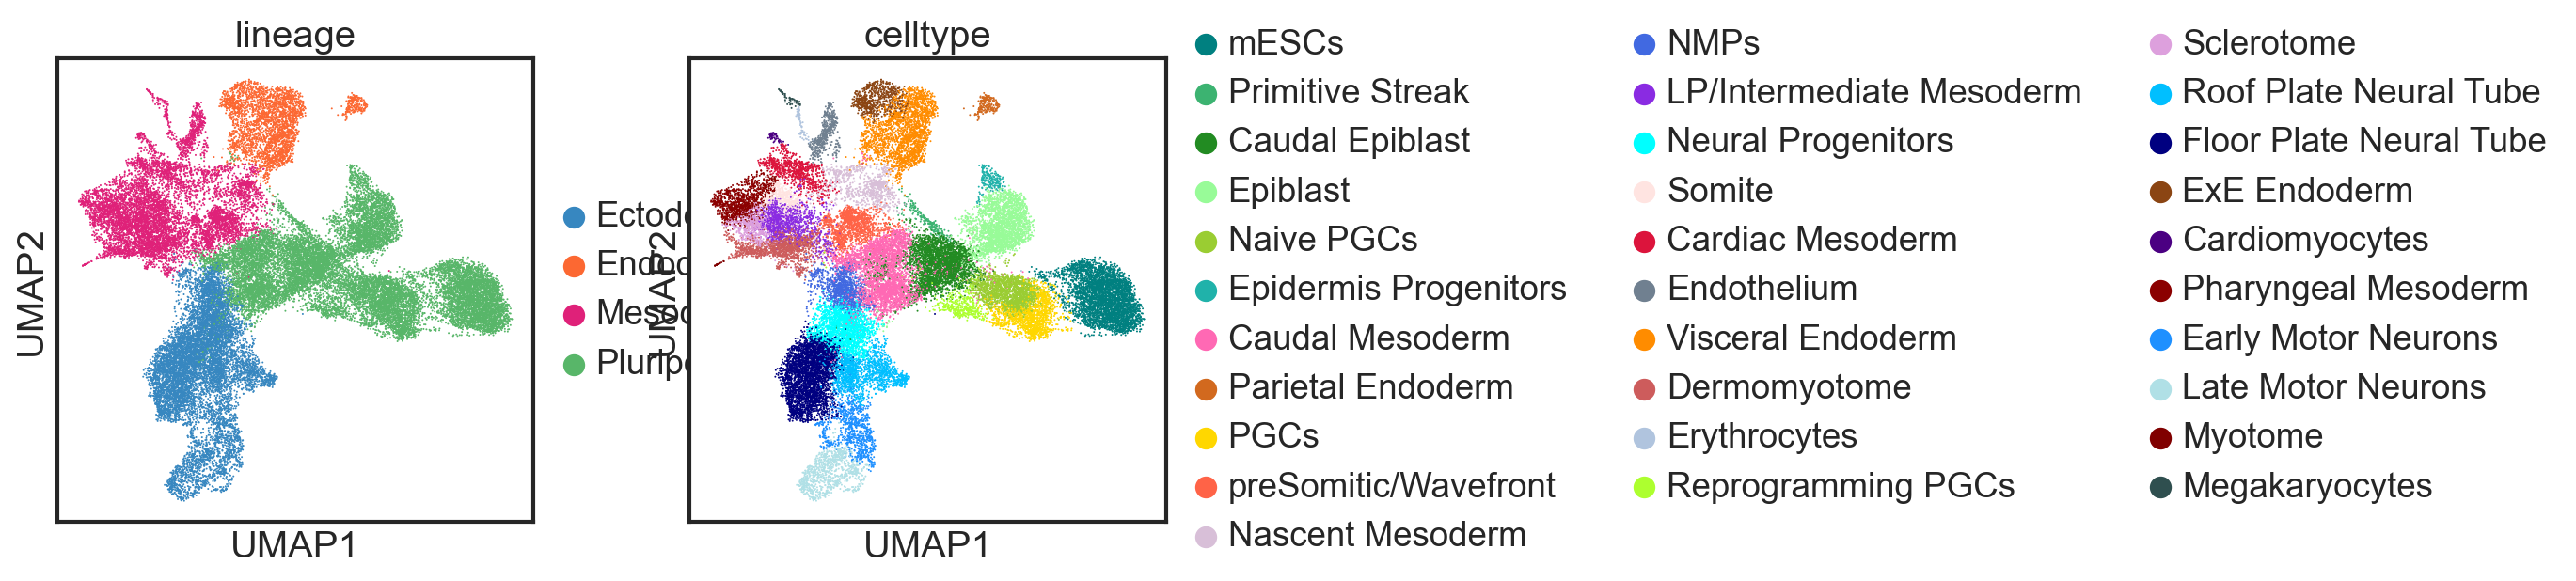

In [6]:
sc.pl.umap(adata, color = ['lineage', 'celltype'])

In [7]:
sc.settings.verbosity = 2

## load the tables with differentially expressed genes

In [8]:
PvsDIFF = pd.read_csv('dfs/20250310_diff_genes_PvsDIFF.csv')
ESCvsP = pd.read_csv('dfs/20250310_diff_genes_ESCvsP.csv')
PvsECT = pd.read_csv('dfs/20250310_diff_genes_PvsECT.csv')
PvsEND = pd.read_csv('dfs/20250310_diff_genes_PvsEND.csv')
PvsMES = pd.read_csv('dfs/20250310_diff_genes_PvsMES.csv')

In [9]:
def up_down_genes(results_df):
    up = results_df[(results_df['padj'] < 0.05) & (results_df['log2FoldChange'] > 2)].sort_values(by = 'log2FoldChange',ascending=True)
    down = results_df[(results_df['padj'] < 0.05) & (results_df['log2FoldChange'] < -2)].sort_values(by = 'log2FoldChange',ascending=True)
    return up,down


In [10]:
PvsDIFF_up, PvsDIFF_down = up_down_genes(PvsDIFF)
ESCvsP_up, ESCvsP_down = up_down_genes(ESCvsP)
PvsECT_up, PvsECT_down = up_down_genes(PvsECT)
PvsEND_up, PvsEND_down = up_down_genes(PvsEND)
PvsMES_up, PvsMES_down = up_down_genes(PvsMES)

# Plotting gene sets

## venn diagrams: check intersect between genesets

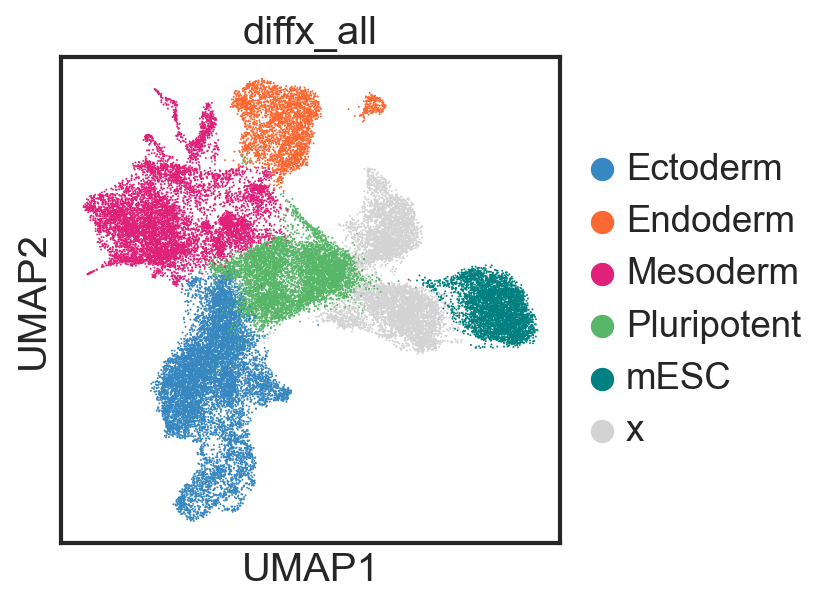

In [11]:
dict_ct = {'Mesoderm':'Mesoderm',
 'Ectoderm':'Ectoderm',
 'Endoderm':'Endoderm',
           'Pluripotent':'Pluripotent'}

adata.obs['diffx_all'] = (
    adata.obs["lineage"]
    .map(lambda x: dict_ct.get(x, x))
    .astype("category")
)

adata.obs['diffx_all'] = adata.obs['diffx_all'].astype(str)
adata.obs.loc[list(adata[adata.obs['celltype'] == 'mESCs'].obs.index), 'diffx_all'] = 'mESC'
adata.obs.loc[list(adata[adata.obs['celltype_general'] == 'PGCs'].obs.index), 'diffx_all'] = 'x'
adata.obs.loc[list(adata[adata.obs['celltype_general'] == 'Epidermis Progenitors'].obs.index), 'diffx_all'] = 'x'
adata.obs.loc[list(adata[adata.obs['celltype_general'] == 'Epiblast'].obs.index), 'diffx_all'] = 'x'

cols = ['#3787c0', '#fc6832','#df2179', '#58b669','teal','lightgrey']
sc.pl.umap(adata, color = 'diffx_all', palette = cols )
color_pal = dict(zip(adata.obs['diffx_all'].cat.categories,adata.uns[str('diffx_all') + '_colors']))


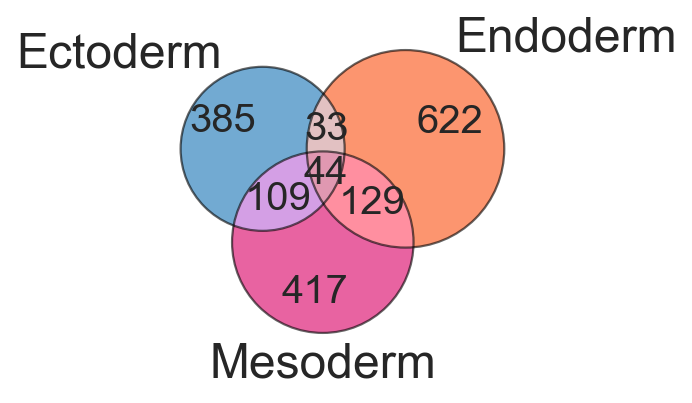

In [12]:
from matplotlib_venn import venn3, venn3_circles

A = PvsECT_up['Gene']
B = PvsEND_up['Gene']
C = PvsMES_up['Gene']

fig,ax = plt.subplots(figsize = (3,3))
venn3([set(A),set(B),set(C)],ax=ax, set_colors = list(color_pal.values())[0:3],set_labels = list(color_pal.keys())[0:3],
      alpha = 0.7)
c = venn3_circles([set(A),set(B),set(C)],color = 'black',linewidth = 1,ax=ax, 
      alpha = 0.6)

#plt.savefig('figs/20250305_venn_overlap_lineages_up.png',bbox_inches='tight')
plt.show()

In [13]:
sc.set_figure_params(dpi = 80)

sns.set_style("white")
sns.set_context("talk")
sns.set_style("ticks")

# Take only unique differentially expressed genes

For the lineages, we take the "up" fraction - these are upregulated in lin vs pluripotent. \
For pluripotency, we take the "down" fraction in p vs diff - these are downregulated in the lineages compared to pluripotency, i.e. they are up in pluripotency. \
For ESCs, we take the "down" fraction in ESC vs p - these are donwregulated in ESCs compared to P. The "up" fraction is differentially expresssed in pluripotent compared to ESCs.

In [15]:
ecto = PvsECT_up[~PvsECT_up['Gene'].isin(list(PvsEND_up['Gene']) + list(PvsMES_up['Gene']))]
meso = PvsMES_up[~PvsMES_up['Gene'].isin(list(PvsEND_up['Gene']) + list(PvsECT_up['Gene']))]
endo = PvsEND_up[~PvsEND_up['Gene'].isin(list(PvsECT_up['Gene']) + list(PvsMES_up['Gene']))]
pluri = PvsDIFF_down

In [17]:
metadata = pd.read_csv('../../tchic_local/fig6_build/dfs/20250215_metadata.tsv', index_col = 0, header = 0, low_memory= False, sep = '\t')

In [18]:
metadata.head(2)

,step,PT,UMAP1,UMAP2,lin,RT,lin2,RT_m,step_id
1,1,0.372537,11.126464,4.599585,ect1,mESCs,Pluripotent mESCs,0.0,1:ect1
2,2,0.463342,11.385221,4.509028,ect1,mESCs,Pluripotent mESCs,0.0,2:ect1


In [21]:
count_table = pd.read_csv('../../tchic_local/fig6_build/dfs/20250304_count_data_all_thresh_min.tsv', sep = '\t', index_col = 0)

In [22]:
count_table.index = count_table['gene']
count_table.head(2)

,gene,step,layer,counts,lin,sm_short,counts_log2,sm_short_log2,sm_short_state_fix,sm_short_state_dyn
gene,,,,,,,,,,
Xkr4,Xkr4,1,RNA,0.25,ect1,0.284,-1.943416,-1.766112,1.0,0.0
Rp1,Rp1,1,RNA,0.23,ect1,0.278,-2.058894,-1.795859,1.0,1.0


In [23]:
d_rna = {}
d_k4 = {}
d_k27 = {}
df_rna = count_table[count_table['layer'] == 'RNA']
df_k4 = count_table[count_table['layer'] == 'K4']
df_k27 = count_table[count_table['layer'] == 'K27']

df_rna = df_rna.drop('gene',axis=1)
df_k4 = df_k4.drop('gene',axis=1)
df_k27 = df_k27.drop('gene',axis=1)

In [24]:
df_rna['p_99'] = df_rna['sm_short']/np.percentile(df_rna['sm_short'],99)
df_k4['p_99'] = df_k4['sm_short']/np.percentile(df_k4['sm_short'],99)
df_k27['p_99'] = df_k27['sm_short']/np.percentile(df_k27['sm_short'],99)

df_rna['p_98'] = df_rna['sm_short']/np.percentile(df_rna['sm_short'],98)
df_k4['p_98'] = df_k4['sm_short']/np.percentile(df_k4['sm_short'],98)
df_k27['p_98'] = df_k27['sm_short']/np.percentile(df_k27['sm_short'],98)

df_rna['p_95'] = df_rna['sm_short']/np.percentile(df_rna['sm_short'],95)
df_k4['p_95'] = df_k4['sm_short']/np.percentile(df_k4['sm_short'],95)
df_k27['p_95'] = df_k27['sm_short']/np.percentile(df_k27['sm_short'],95)

In [25]:
ct_normalised = pd.concat([df_rna,df_k4,df_k27])

In [26]:
ct_normalised.head(2)

,step,layer,counts,lin,sm_short,counts_log2,sm_short_log2,sm_short_state_fix,sm_short_state_dyn,p_99,p_98,p_95
gene,,,,,,,,,,,,
Xkr4,1,RNA,0.25,ect1,0.284,-1.943416,-1.766112,1.0,0.0,0.047819,0.069934,0.125110
Rp1,1,RNA,0.23,ect1,0.278,-2.058894,-1.795859,1.0,1.0,0.046809,0.068456,0.122467


In [27]:
ct_normalised['p98_log2'] = np.log2(ct_normalised['p_98']+1)
ct_normalised['p98_log10'] = np.log10(ct_normalised['p_98']+1)

ct_normalised['step_id'] = ct_normalised['step'].astype(str) + str(':') + ct_normalised['lin']
metadata['step_id'] = metadata['step'].astype(str) + str(':') + metadata['lin']
steps_to_RT = metadata[['step_id','RT']].set_index('step_id').to_dict()['RT']
ct_normalised['RT'] = ct_normalised['step_id'].map(steps_to_RT)
ct_normalised['RT'] = ct_normalised['RT'].astype('category')
ct_normalised['RT'] = ct_normalised['RT'].cat.reorder_categories(['mESCs','Gastd3', 'Gastd4', 'Gastd5', 'Gastd6', 'Gastd7'])
ct_normalised['lin_layer'] = ct_normalised['lin'].astype(str) + str('_') + ct_normalised['layer'].astype(str)


In [28]:
ct_normalised.head(2)

,step,layer,counts,lin,sm_short,counts_log2,sm_short_log2,sm_short_state_fix,sm_short_state_dyn,p_99,p_98,p_95,p98_log2,p98_log10,step_id,RT,lin_layer
gene,,,,,,,,,,,,,,,,,
Xkr4,1,RNA,0.25,ect1,0.284,-1.943416,-1.766112,1.0,0.0,0.047819,0.069934,0.125110,0.097521,0.029357,1:ect1,mESCs,ect1_RNA
Rp1,1,RNA,0.23,ect1,0.278,-2.058894,-1.795859,1.0,1.0,0.046809,0.068456,0.122467,0.095528,0.028757,1:ect1,mESCs,ect1_RNA


In [29]:
to_plot1 = ct_normalised.loc[list(set(endo['Gene']) & set(ct_normalised.index))]
to_plot2 = ct_normalised.loc[list(set(meso['Gene']) & set(ct_normalised.index))]
to_plot3 = ct_normalised.loc[list(set(ecto['Gene']) & set(ct_normalised.index))]
to_plot4 = ct_normalised.loc[list(set(pluri['Gene']) & set(ct_normalised.index))]

In [30]:
lin_colors = {'Ectoderm':'#3787C0', 'Endoderm':'#FC6832', 'Mesoderm':'#DF2179'}
Green='#238b45'
Purple='#6a51a3'
Orange='#d94801'

lightOrange = '#f59c71'
lightGreen = '#90f5b1'
lightPurple = '#b698fa'

# identify state changes

In [31]:
def findStateChanges(df, state = 'sm_short_state_dyn', val = 'sm_short'):
    df = df.reset_index().set_index(['step','gene','layer','lin'])
    df2 = df.copy()
    idx =df2.reset_index()['step']+1
    df2 = df2.reset_index().set_index([idx,'gene','layer','lin'])

    #add change
    df['change'] = df[state] - df2[state]
    #add val change compared to step-1
    df['val_change'] = df[val] - df2[val]
    #add val change compared to step 1

    #extract the number of steps per trajectory
    dict1 = {}
    for x in df2['lin_layer'].unique():
        dict1[x] = df2[df2['lin_layer'] == x]['step'].max()
    #take all values for step 1
    steps_1 = df2[df2['step'] == 1][[val,'lin_layer']]
    # add total n steps per trajectory 
    steps_1['counts'] = steps_1['lin_layer'].replace(dict1)

    # multiply step 1 by length of trajectory
    all_steps_1 = []
    for num in range(steps_1.shape[0]):
        all_steps_1.extend([steps_1[val].iloc[num]]* steps_1['counts'].iloc[num])

    # add all step 1s as a column
    df['steps1'] = all_steps_1
    #substract value of step n from value of step 1
    df['total_change'] = df['steps1'] - df[val]
    
    return df[df['change'] != 0].dropna().reset_index()

    

In [32]:
end_changes = findStateChanges(to_plot1.drop(['p_99','p_98', 'p_95', 'p98_log2', 'p98_log10', 'step_id'], axis = 1),state = 'sm_short_state_dyn')
end_changes.head(2)

/var/folders/_k/c0bkq2m10c5f4h7vq_0xfm_40000gn/T/ipykernel_14024/731907501.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  steps_1['counts'] = steps_1['lin_layer'].replace(dict1)


,step,gene,layer,lin,counts,sm_short,counts_log2,sm_short_log2,sm_short_state_fix,sm_short_state_dyn,RT,lin_layer,change,val_change,steps1,total_change
0,121,Sdsl,K27,ect1,0.10,0.126667,-3.184425,-2.871267,1.0,0.0,Gastd5,ect1_K27,-1.0,-0.016000,0.48,0.353333
1,123,Sdsl,K27,ect1,0.02,0.136000,-5.058894,-2.775960,1.0,1.0,Gastd5,ect1_K27,1.0,0.018667,0.48,0.344000


In [33]:
mes_changes = findStateChanges(to_plot2.drop(['p_99','p_98', 'p_95', 'p98_log2', 'p98_log10', 'step_id'], axis = 1),state = 'sm_short_state_dyn')
mes_changes.head(2)

/var/folders/_k/c0bkq2m10c5f4h7vq_0xfm_40000gn/T/ipykernel_14024/731907501.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  steps_1['counts'] = steps_1['lin_layer'].replace(dict1)


,step,gene,layer,lin,counts,sm_short,counts_log2,sm_short_log2,sm_short_state_fix,sm_short_state_dyn,RT,lin_layer,change,val_change,steps1,total_change
0,129,Hba-a1,K27,ect1,0.24,0.205333,-2.000000,-2.215356,1.0,0.0,Gastd5,ect1_K27,-1.0,-0.008000,0.4325,0.227167
1,128,Hba-a1,K27,ect2,0.34,0.206667,-1.514573,-2.206451,1.0,0.0,Gastd6,ect2_K27,-1.0,-0.017333,0.4325,0.225833


In [34]:
ect_changes = findStateChanges(to_plot3.drop(['p_99','p_98', 'p_95', 'p98_log2', 'p98_log10', 'step_id'], axis = 1),state = 'sm_short_state_dyn')
ect_changes.head(2)

/var/folders/_k/c0bkq2m10c5f4h7vq_0xfm_40000gn/T/ipykernel_14024/731907501.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  steps_1['counts'] = steps_1['lin_layer'].replace(dict1)


,step,gene,layer,lin,counts,sm_short,counts_log2,sm_short_log2,sm_short_state_fix,sm_short_state_dyn,RT,lin_layer,change,val_change,steps1,total_change
0,123,Gsx1,K4,ect1,0.02,0.030667,-5.058894,-4.620009,1.0,0.0,Gastd5,ect1_K4,-1.0,-0.002667,0.105,0.074333
1,125,Gsx1,K4,ect1,0.02,0.033333,-5.058894,-4.528379,1.0,1.0,Gastd5,ect1_K4,1.0,0.004000,0.105,0.071667


In [35]:
p_changes = findStateChanges(to_plot4.drop(['p_99','p_98', 'p_95', 'p98_log2', 'p98_log10', 'step_id'], axis = 1),state = 'sm_short_state_dyn')
p_changes.head(2)

/var/folders/_k/c0bkq2m10c5f4h7vq_0xfm_40000gn/T/ipykernel_14024/731907501.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  steps_1['counts'] = steps_1['lin_layer'].replace(dict1)


,step,gene,layer,lin,counts,sm_short,counts_log2,sm_short_log2,sm_short_state_fix,sm_short_state_dyn,RT,lin_layer,change,val_change,steps1,total_change
0,11,Ano5,RNA,ect1,0.04,0.030,-4.321928,-4.643856,1.0,0.0,mESCs,ect1_RNA,-1.0,-0.008,0.048,0.018
1,13,Ano5,RNA,ect1,0.03,0.033,-4.643856,-4.539520,1.0,1.0,mESCs,ect1_RNA,1.0,0.003,0.048,0.015


# Check step changes between RNA and K27me3

In [36]:
def plotRNAvsK27(df, lin = 'ect1', col = 'Ectoderm', keep = False,save = None):
    df['dup'] = df['lin_layer'] + '_' + df['gene']
    df_unique = df[~df['dup'].duplicated(keep = keep)]
    k27 = df_unique[(df_unique['layer'] == 'K27') & (df_unique['lin'] == lin)][['gene','step']].set_index(['gene']).rename(columns={'step':'k27'})
    rna = df_unique[(df_unique['layer'] == 'RNA') & (df_unique['lin'] == lin)][['gene','step']].set_index(['gene']).rename(columns={'step':'rna'})

    plt.axline((1, 1), slope=1, linestyle = 'dashed', c = 'black')
    #extract the number of steps per trajectory
    dict1 = {}
    for x in df['lin_layer'].unique():
        dict1[x] = df[df['lin_layer'] == x]['step'].max()
        
    sns.scatterplot(data = rna.join(k27, how = 'inner'),
                    x = 'rna',
                    y = 'k27', s = 40, alpha = 0.7,zorder = 1,
                   color = color_pal[col])
    plt.xlim([0,dict1[lin+'_RNA']+5])
    plt.ylim([0,dict1[lin+'_RNA']+5])
    plt.title(lin)
    if save != None:
        plt.savefig(save, bbox_inches = 'tight')
    plt.show()
    

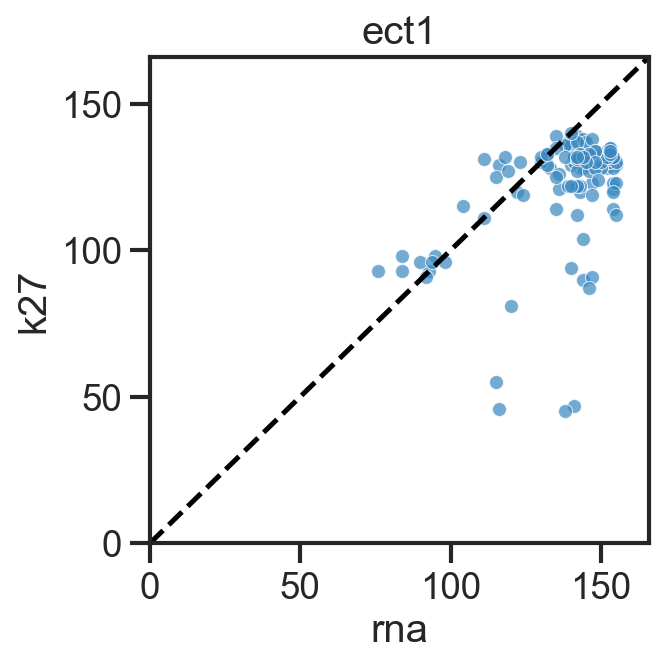

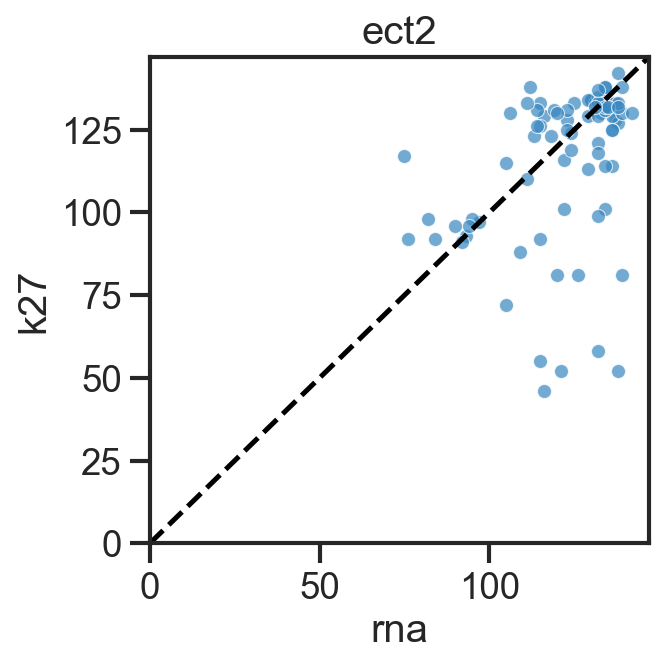

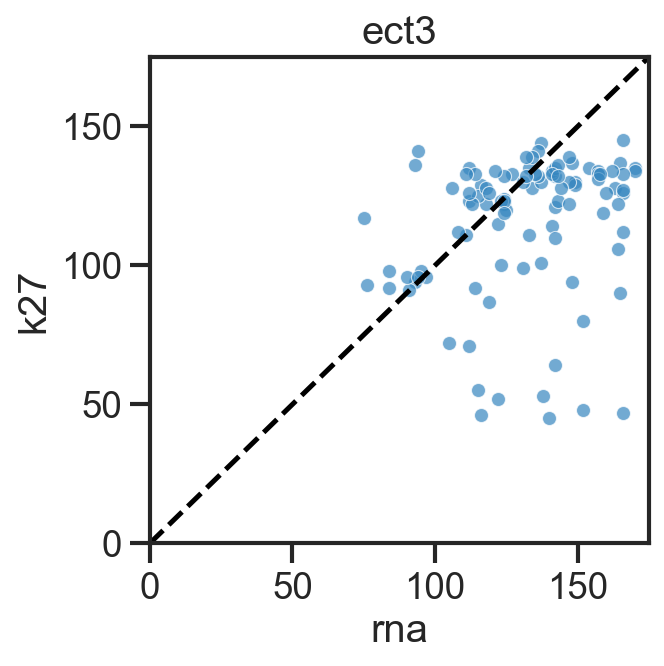

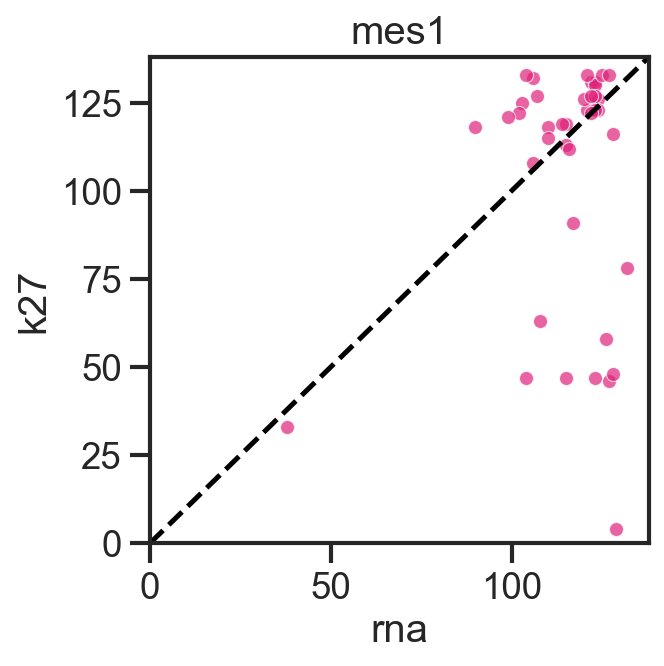

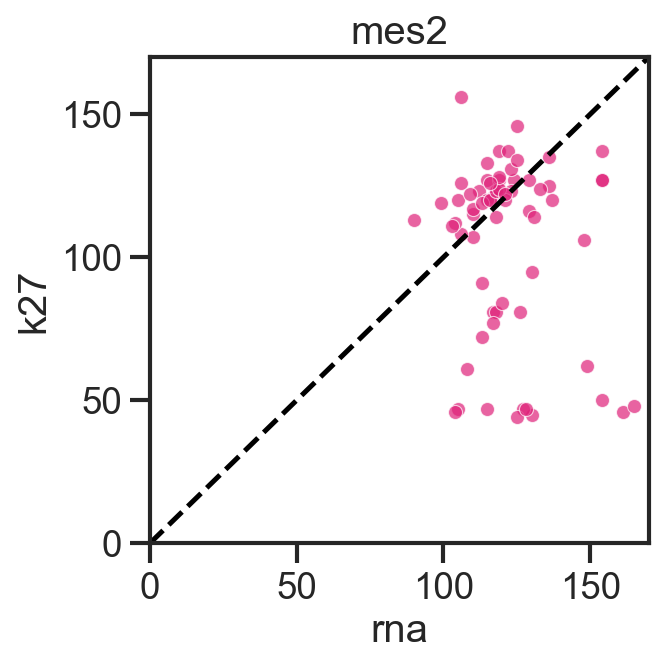

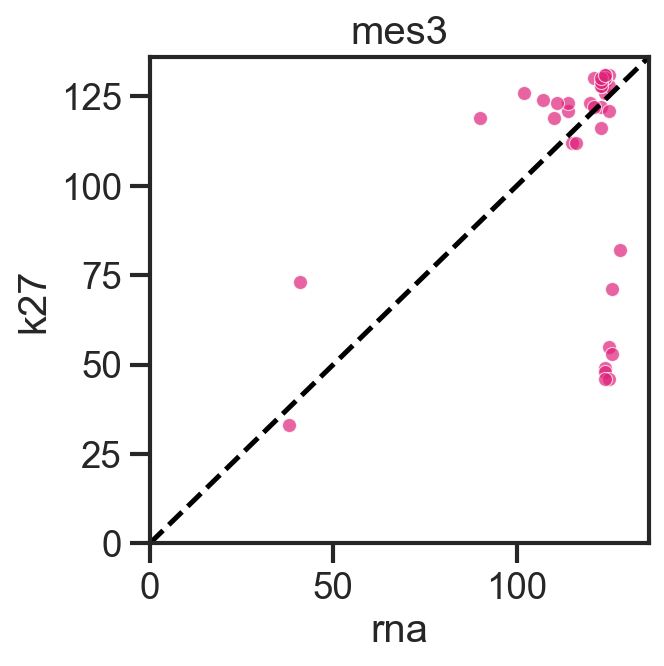

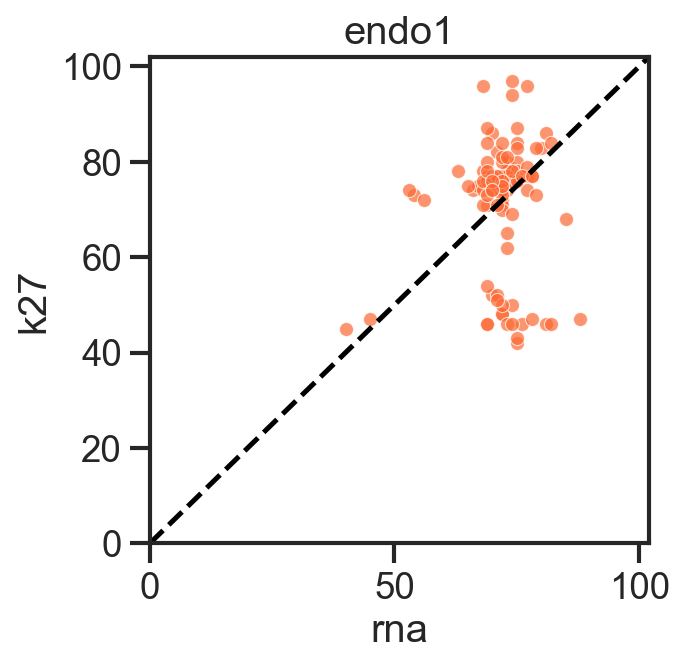

In [37]:
plotRNAvsK27(ect_changes,'ect1',col = 'Ectoderm')
plotRNAvsK27(ect_changes,'ect2',col = 'Ectoderm')
plotRNAvsK27(ect_changes,'ect3',col = 'Ectoderm')

plotRNAvsK27(mes_changes,'mes1',col = 'Mesoderm')
plotRNAvsK27(mes_changes,'mes2',col = 'Mesoderm')
plotRNAvsK27(mes_changes,'mes3',col = 'Mesoderm')

plotRNAvsK27(end_changes,'endo1',col = 'Endoderm')

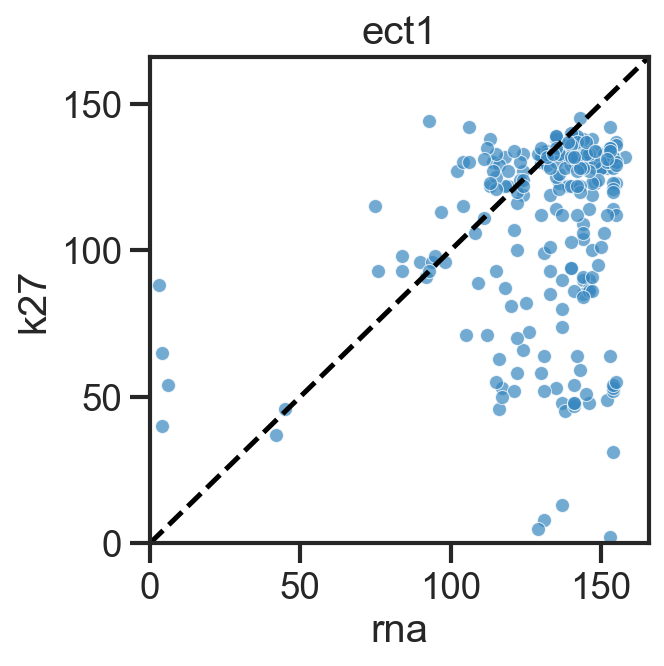

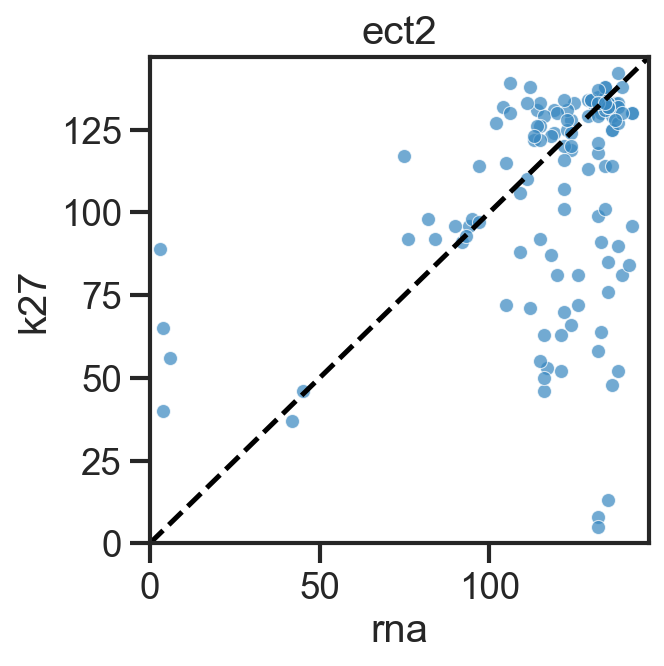

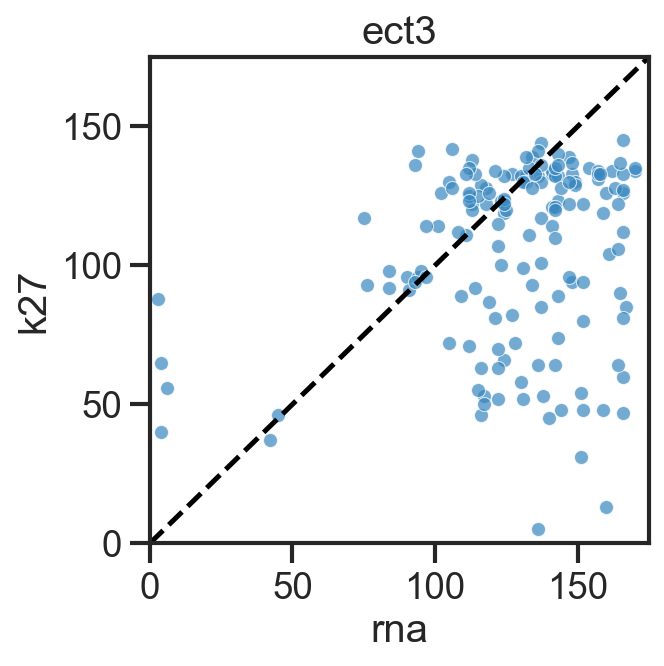

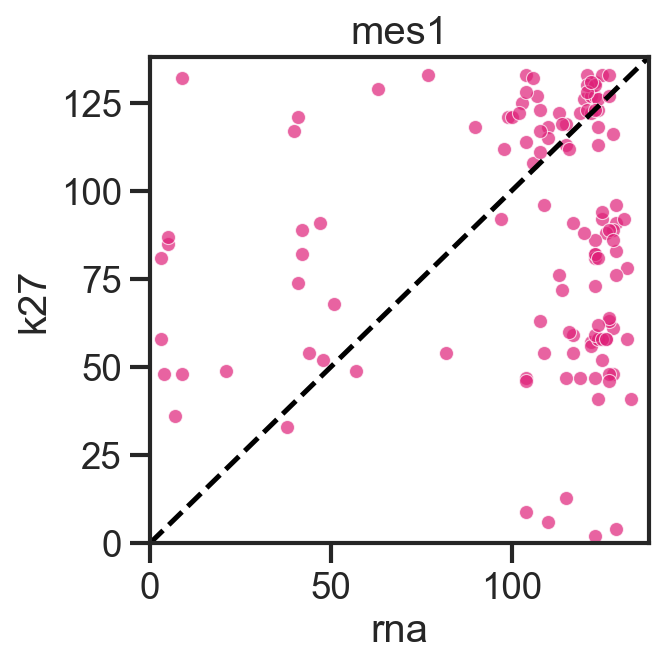

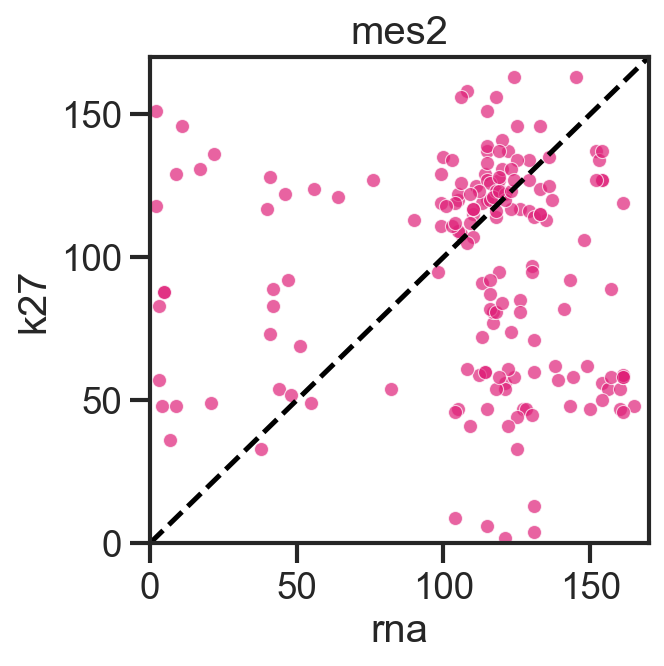

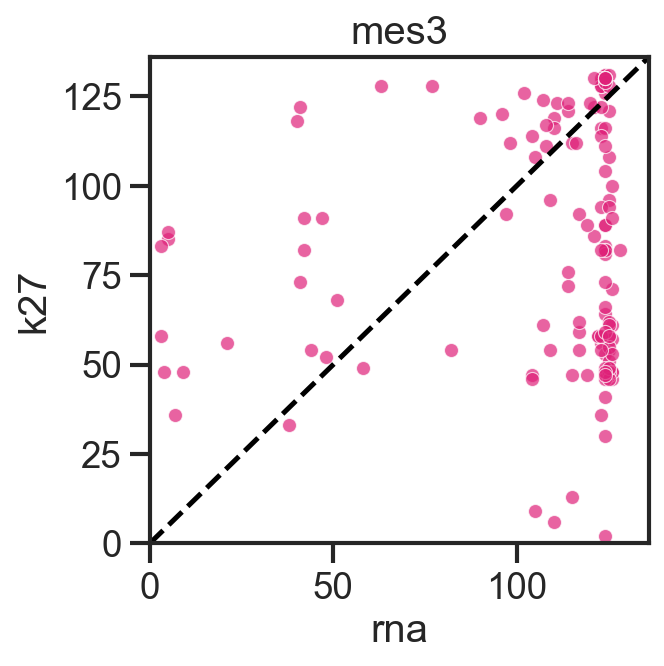

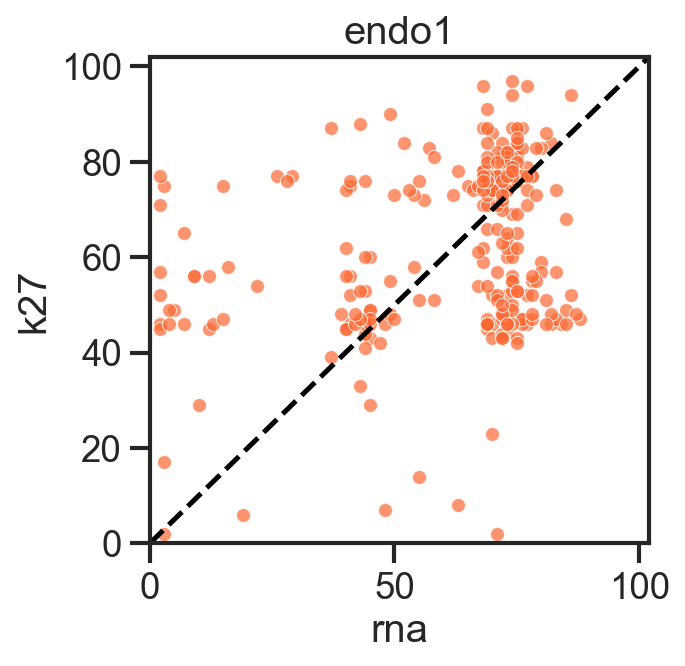

In [38]:
plotRNAvsK27(ect_changes,'ect1',col = 'Ectoderm',keep = 'first', save = 'figs/scatter_rna_vs_k27_ect1.png')
plotRNAvsK27(ect_changes,'ect2',col = 'Ectoderm',keep = 'first', save = 'figs/scatter_rna_vs_k27_ect2.png')
plotRNAvsK27(ect_changes,'ect3',col = 'Ectoderm',keep = 'first', save = 'figs/scatter_rna_vs_k27_ect3.png')

plotRNAvsK27(mes_changes,'mes1',col = 'Mesoderm',keep = 'first', save = 'figs/scatter_rna_vs_k27_mes1.png')
plotRNAvsK27(mes_changes,'mes2',col = 'Mesoderm',keep = 'first', save = 'figs/scatter_rna_vs_k27_mes2.png')
plotRNAvsK27(mes_changes,'mes3',col = 'Mesoderm',keep = 'first', save = 'figs/scatter_rna_vs_k27_mes3.png')

plotRNAvsK27(end_changes,'endo1',col = 'Endoderm',keep = 'first', save = 'figs/scatter_rna_vs_k27_end1.png')

In [38]:
def plotRNAvsK27(df, lin = 'ect1', col = 'Ectoderm', keep = False):
    df['dup'] = df['lin_layer'] + '_' + df['gene']
    df_unique = df[~df['dup'].duplicated(keep = keep)]
    k27 = df_unique[(df_unique['layer'] == 'K27') & (df_unique['lin'] == lin)][['gene','step']].set_index(['gene']).rename(columns={'step':'k27'})
    rna = df_unique[(df_unique['layer'] == 'RNA') & (df_unique['lin'] == lin)][['gene','step']].set_index(['gene']).rename(columns={'step':'rna'})

    plt.axline((1, 1), slope=1, linestyle = 'dashed', c = 'black')
    
    sns.scatterplot(data = rna.join(k27, how = 'inner'),
                    x = 'rna',
                    y = 'k27', s = 40, alpha = 0.7,zorder = 1,
                   color = color_pal[col])
    plt.xlim([0,dict1[lin+'_RNA']+5])
    plt.ylim([0,dict1[lin+'_RNA']+5])
    plt.title(lin)
    plt.show()
    

In [39]:
def calculateDiff(df, lin, keep = False, mark = 'K27'):
    df['dup'] = df['lin_layer'] + '_' + df['gene']
    df_unique = df[~df['dup'].duplicated(keep = keep)]
    k27 = df_unique[(df_unique['layer'] == mark) & (df_unique['lin'] == lin)][['gene','step']].set_index(['gene']).rename(columns={'step':mark})
    rna = df_unique[(df_unique['layer'] == 'RNA') & (df_unique['lin'] == lin)][['gene','step']].set_index(['gene']).rename(columns={'step':'rna'})
    joined = rna.join(k27, how = 'inner')
    joined['diff'] = joined[mark]-joined['rna']
    joined['lin'] = lin
    
    return joined

In [40]:
d1 = calculateDiff(ect_changes,'ect1',keep = 'first')
d2 = calculateDiff(ect_changes,'ect2',keep = 'first')
d3 = calculateDiff(ect_changes,'ect3',keep = 'first')

d4 = calculateDiff(mes_changes,'mes1',keep = 'first')
d5 = calculateDiff(mes_changes,'mes2',keep = 'first')
d6 = calculateDiff(mes_changes,'mes3',keep = 'first')

d7 = calculateDiff(end_changes,'endo1',keep = 'first')

# Define stdev cutoff

RNA
([0.2643390517921977],)


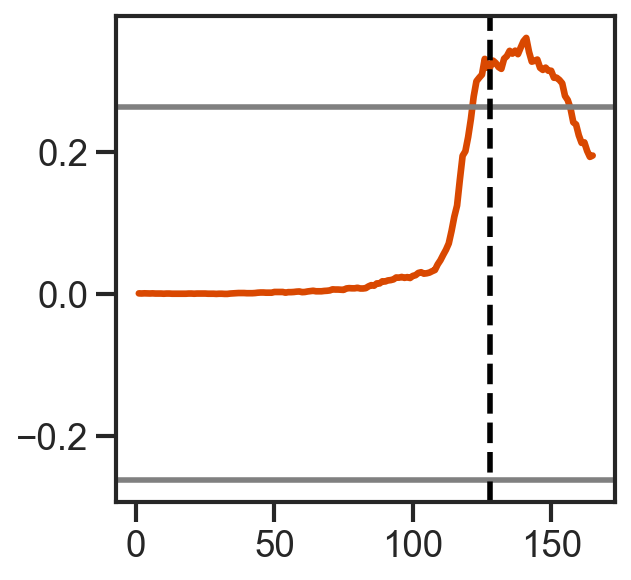

K27
([1.055872507655846],)


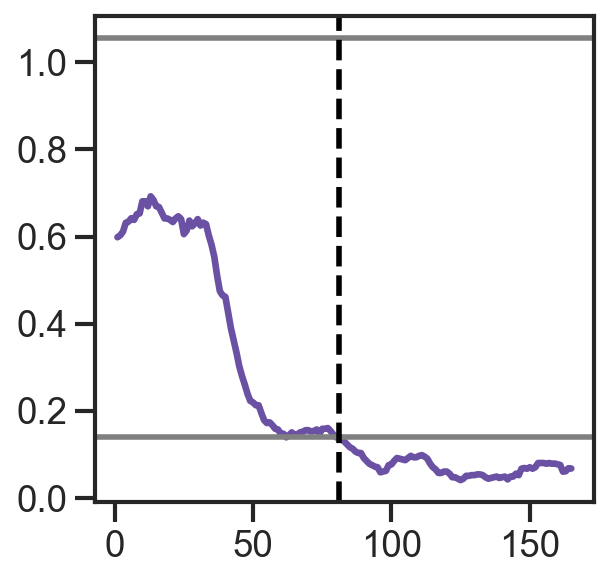

K4
([1.0321310597807491],)


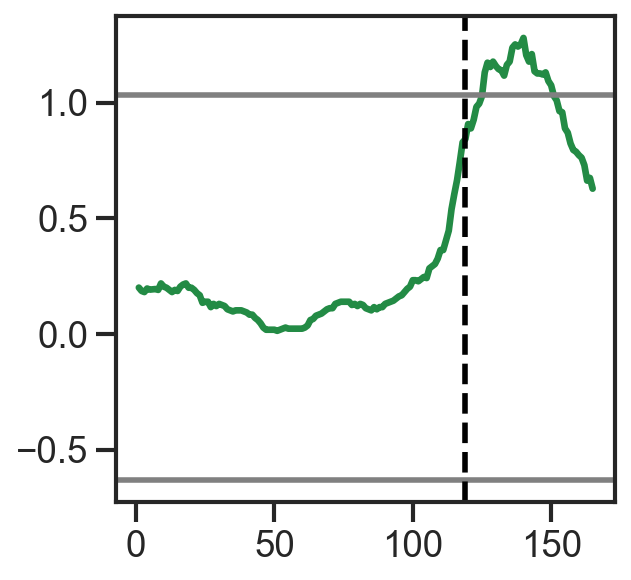

In [46]:
gene = 'Meox1'#'Tnfrsf12a'#'Habp2'
lin = 'mes2'

vals = 'p_98'

mods = ['RNA','K27', 'K4']
stepchange = [128, 81, 119]

pal = [Orange,Purple,Green]
for num,x in enumerate(mods):
    print(x)
    testgene = ct_normalised[(ct_normalised['lin'] == lin) & (ct_normalised.index == gene)]
    
    sns.lineplot(data = testgene,
                 x = 'step',
                 y = vals,
                 hue = 'layer', hue_order = [x],linewidth = 3,
                 palette = [pal[num]])
    val = list(testgene[(testgene['layer'] == x) & (testgene['step'] == 1)][vals]+np.std(testgene[testgene['layer'] == x][vals])*2),
    print(val)
    plt.axhline(val,linewidth = 2.5,
               c = 'gray')#linestyle = 'dashed')
    plt.axhline(list(testgene[(testgene['layer'] == x) & (testgene['step'] == 1)][vals]-np.std(testgene[testgene['layer'] == x][vals])*2),
                linewidth = 2.5,
                c = 'gray')#, linestyle = 'dashed')
    plt.axvline(stepchange[num],linewidth = 2.5,
                c = 'black', linestyle = 'dashed')
    #plt.ylim([-0.2, 0.75])
    plt.ylabel('')
    plt.xlabel('')
    plt.legend([], frameon = False)
    plt.savefig('figs/20250417_stdev_QClineplot_' + str(x) + '.png')
    plt.show()


In [47]:
def calculate_stdev(df, val = 'sm_short'):
    print('pivot table...')
    df_pivot = df[['step','layer','lin',val,'lin_layer', 'step_id','RT']].reset_index().pivot(index = ['gene','lin','layer'], 
                                                                              columns = ['step'],
                                                                              values = [val])
    print('calculate stdev...')
    upper = df_pivot.iloc[:,0] + np.std(df_pivot, axis = 1)*2
    lower = df_pivot.iloc[:,0] - np.std(df_pivot, axis = 1)*2
    df_std = pd.DataFrame([lower,upper]).T.rename(columns = {0:'lower',1:'upper'}).reset_index()
    df_std['gene_lin_layer'] = df_std['gene'] + '_' + df_std['lin'] + '_' + df_std['layer']

    lower = dict(zip(df_std['gene_lin_layer'], df_std['lower']))
    upper = dict(zip(df_std['gene_lin_layer'], df_std['upper']))

    print('add to table...')
    df = df.reset_index()
    df['gene_lin_layer'] = df['gene'] + '_' + df['lin'] + '_' + df['layer']

    df['std_lower'] = df['gene_lin_layer'].map(lower)
    df['std_upper'] = df['gene_lin_layer'].map(upper)

    return df


In [48]:
ct_normalised_clean = ct_normalised[['step','layer','lin','sm_short','lin_layer', 'step_id','RT']]

In [49]:
stdev_all = calculate_stdev(ct_normalised_clean)

pivot table...
calculate stdev...
add to table...


In [50]:
stdev_all.head(2)

,gene,step,layer,lin,sm_short,lin_layer,step_id,RT,gene_lin_layer,std_lower,std_upper
0,Xkr4,1,RNA,ect1,0.284,ect1_RNA,1:ect1,mESCs,Xkr4_ect1_RNA,-14.691952,15.259952
1,Rp1,1,RNA,ect1,0.278,ect1_RNA,1:ect1,mESCs,Rp1_ect1_RNA,0.130064,0.425936


In [51]:
stdev_all['state'] = 0
stdev_all.loc[(stdev_all['sm_short'] < stdev_all['std_lower']), 'state'] =-1
stdev_all.loc[(stdev_all['sm_short'] > stdev_all['std_upper']), 'state'] =+1

In [52]:
std_endo = stdev_all[stdev_all['gene'].isin(list(set(endo['Gene']) & set(stdev_all['gene'])))]
std_meso = stdev_all[stdev_all['gene'].isin(list(set(meso['Gene']) & set(stdev_all['gene'])))]
std_ecto = stdev_all[stdev_all['gene'].isin(list(set(ecto['Gene']) & set(stdev_all['gene'])))]
std_plur = stdev_all[stdev_all['gene'].isin(list(set(pluri['Gene']) & set(stdev_all['gene'])))]

In [53]:
endo_changes = findStateChanges(std_endo, state = 'state', val = 'sm_short')

/var/folders/_k/c0bkq2m10c5f4h7vq_0xfm_40000gn/T/ipykernel_14024/731907501.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  steps_1['counts'] = steps_1['lin_layer'].replace(dict1)


In [54]:
endo_changes_unique = endo_changes[~endo_changes['gene_lin_layer'].duplicated(keep='first')]

In [55]:
meso_changes = findStateChanges(std_meso, state = 'state', val = 'sm_short')

/var/folders/_k/c0bkq2m10c5f4h7vq_0xfm_40000gn/T/ipykernel_14024/731907501.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  steps_1['counts'] = steps_1['lin_layer'].replace(dict1)


In [56]:
meso_changes_unique = meso_changes[~meso_changes['gene_lin_layer'].duplicated(keep='first')]

In [57]:
ecto_changes = findStateChanges(std_ecto, state = 'state', val = 'sm_short')

/var/folders/_k/c0bkq2m10c5f4h7vq_0xfm_40000gn/T/ipykernel_14024/731907501.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  steps_1['counts'] = steps_1['lin_layer'].replace(dict1)


In [58]:
ecto_changes_unique = ecto_changes[~ecto_changes['gene_lin_layer'].duplicated(keep='first')]

In [59]:
plur_changes = findStateChanges(std_plur, state = 'state', val = 'sm_short')

/var/folders/_k/c0bkq2m10c5f4h7vq_0xfm_40000gn/T/ipykernel_14024/731907501.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  steps_1['counts'] = steps_1['lin_layer'].replace(dict1)


In [60]:
plur_changes_unique = plur_changes[~plur_changes['gene_lin_layer'].duplicated(keep='first')]

In [61]:
endo_changes_f = endo_changes_unique[((endo_changes_unique['layer'] == 'RNA') & (endo_changes_unique['change'] == 1)) | ((endo_changes_unique['layer'] == 'K4') & (endo_changes_unique['change'] == 1)) | ((endo_changes_unique['layer'] == 'K27') & (endo_changes_unique['change'] == -1))]

In [62]:
meso_changes_f = meso_changes_unique[((meso_changes_unique['layer'] == 'RNA') & (meso_changes_unique['change'] == 1)) | ((meso_changes_unique['layer'] == 'K4') & (meso_changes_unique['change'] == 1)) | ((meso_changes_unique['layer'] == 'K27') & (meso_changes_unique['change'] == -1))]

In [63]:
ecto_changes_f = ecto_changes_unique[((ecto_changes_unique['layer'] == 'RNA') & (ecto_changes_unique['change'] == 1)) | ((ecto_changes_unique['layer'] == 'K4') & (ecto_changes_unique['change'] == 1)) | ((ecto_changes_unique['layer'] == 'K27') & (ecto_changes_unique['change'] == -1))]

In [64]:
plur_changes_f = plur_changes_unique[((plur_changes_unique['layer'] == 'RNA') & (plur_changes_unique['change'] == 1)) | ((plur_changes_unique['layer'] == 'K4') & (plur_changes_unique['change'] == 1)) | ((plur_changes_unique['layer'] == 'K27') & (plur_changes_unique['change'] == -1))]

In [65]:
#meso_2 = meso_changes_f[meso_changes_f['gene'].isin(pd.DataFrame(meso_changes_f[['gene','lin']].value_counts()[meso_changes_f[['gene','lin']].value_counts() >1]).reset_index()['gene'].unique())]

meso_all_3 = meso_changes_f[meso_changes_f['gene'].isin(pd.DataFrame(meso_changes_f[['gene','lin']].value_counts()[meso_changes_f[['gene','lin']].value_counts() == 3]).reset_index()['gene'].unique())]
meso_all_3.head(2)

,step,gene,layer,lin,index,sm_short,lin_layer,step_id,RT,gene_lin_layer,std_lower,std_upper,state,change,val_change,steps1,total_change
30,8,Tdo2,RNA,ect1,131218,0.009,ect1_RNA,8:ect1,mESCs,Tdo2_ect1_RNA,-0.000348,0.008348,1,1.0,0.002,0.038,0.029
35,9,Myocos,RNA,ect1,139346,0.018,ect1_RNA,9:ect1,mESCs,Myocos_ect1_RNA,0.000574,0.015426,1,1.0,0.006,0.004,-0.014


In [66]:
endo_K27RNA_changing = list(pd.DataFrame(endo_changes_f[endo_changes_f['layer'] != 'K4'][['gene','lin']].value_counts()[endo_changes_f[endo_changes_f['layer'] != 'K4'][['gene','lin']].value_counts() == 2]).reset_index()['gene'].unique())

meso_K27RNA_changing = list(pd.DataFrame(meso_changes_f[meso_changes_f['layer'] != 'K4'][['gene','lin']].value_counts()[meso_changes_f[meso_changes_f['layer'] != 'K4'][['gene','lin']].value_counts() == 2]).reset_index()['gene'].unique())

ecto_K27RNA_changing = list(pd.DataFrame(ecto_changes_f[ecto_changes_f['layer'] != 'K4'][['gene','lin']].value_counts()[ecto_changes_f[ecto_changes_f['layer'] != 'K4'][['gene','lin']].value_counts() == 2]).reset_index()['gene'].unique())



print(len(endo_K27RNA_changing), len(meso_K27RNA_changing),len(ecto_K27RNA_changing))

427 300 227


In [69]:
endo_K27RNA_changing = list(pd.DataFrame(endo_changes_f[endo_changes_f['layer'] != 'K4'][['gene','lin']].value_counts()[endo_changes_f[endo_changes_f['layer'] != 'K4'][['gene','lin']].value_counts() == 2]).reset_index()['gene'].unique())
meso_K27RNA_changing = list(pd.DataFrame(meso_changes_f[meso_changes_f['layer'] != 'K4'][['gene','lin']].value_counts()[meso_changes_f[meso_changes_f['layer'] != 'K4'][['gene','lin']].value_counts() == 2]).reset_index()['gene'].unique())
ecto_K27RNA_changing = list(pd.DataFrame(ecto_changes_f[ecto_changes_f['layer'] != 'K4'][['gene','lin']].value_counts()[ecto_changes_f[ecto_changes_f['layer'] != 'K4'][['gene','lin']].value_counts() == 2]).reset_index()['gene'].unique())

endo_K4RNA_changing = list(pd.DataFrame(endo_changes_f[endo_changes_f['layer'] != 'K27'][['gene','lin']].value_counts()[endo_changes_f[endo_changes_f['layer'] != 'K27'][['gene','lin']].value_counts() == 2]).reset_index()['gene'].unique())
meso_K4RNA_changing = list(pd.DataFrame(meso_changes_f[meso_changes_f['layer'] != 'K27'][['gene','lin']].value_counts()[meso_changes_f[meso_changes_f['layer'] != 'K27'][['gene','lin']].value_counts() == 2]).reset_index()['gene'].unique())
ecto_K4RNA_changing = list(pd.DataFrame(ecto_changes_f[ecto_changes_f['layer'] != 'K27'][['gene','lin']].value_counts()[ecto_changes_f[ecto_changes_f['layer'] != 'K27'][['gene','lin']].value_counts() == 2]).reset_index()['gene'].unique())

endo_allchanging = list(pd.DataFrame(endo_changes_f[['gene','lin']].value_counts()[endo_changes_f[['gene','lin']].value_counts() == 3]).reset_index()['gene'].unique())
meso_allchanging = list(pd.DataFrame(meso_changes_f[['gene','lin']].value_counts()[meso_changes_f[['gene','lin']].value_counts() == 3]).reset_index()['gene'].unique())
ecto_allchanging = list(pd.DataFrame(ecto_changes_f[['gene','lin']].value_counts()[ecto_changes_f[['gene','lin']].value_counts() == 3]).reset_index()['gene'].unique())

print(len(endo_K27RNA_changing), len(meso_K27RNA_changing),len(ecto_K27RNA_changing))

427 300 227


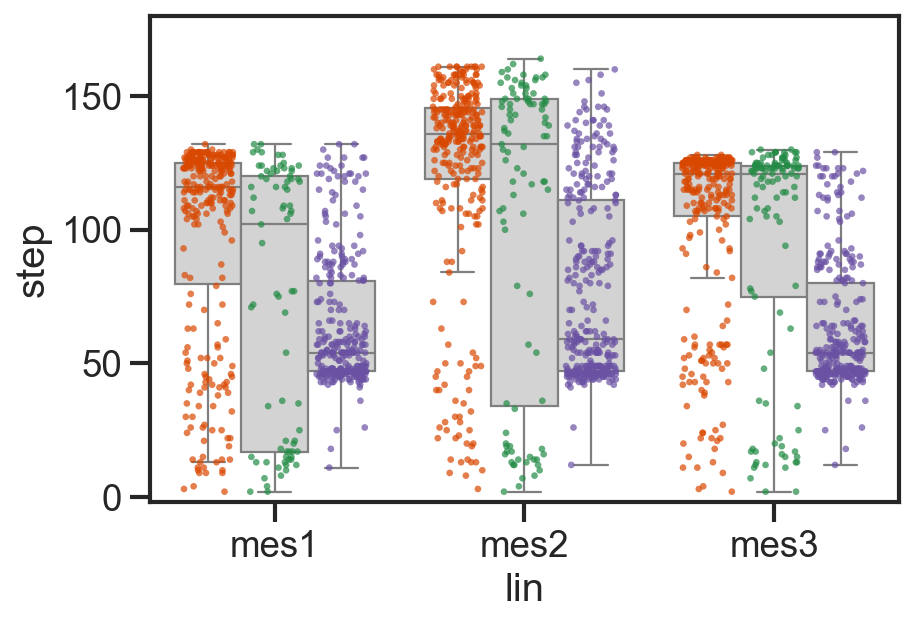

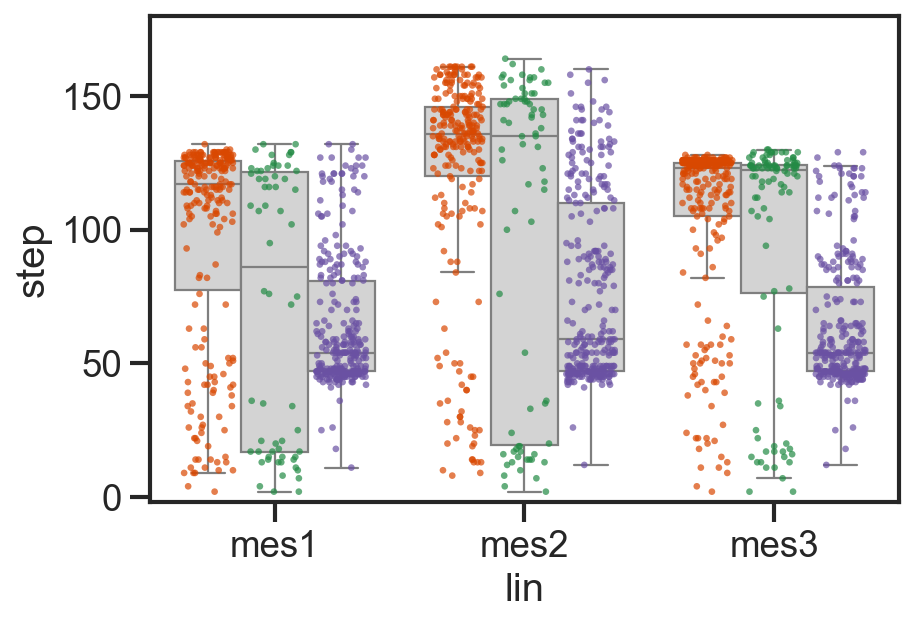

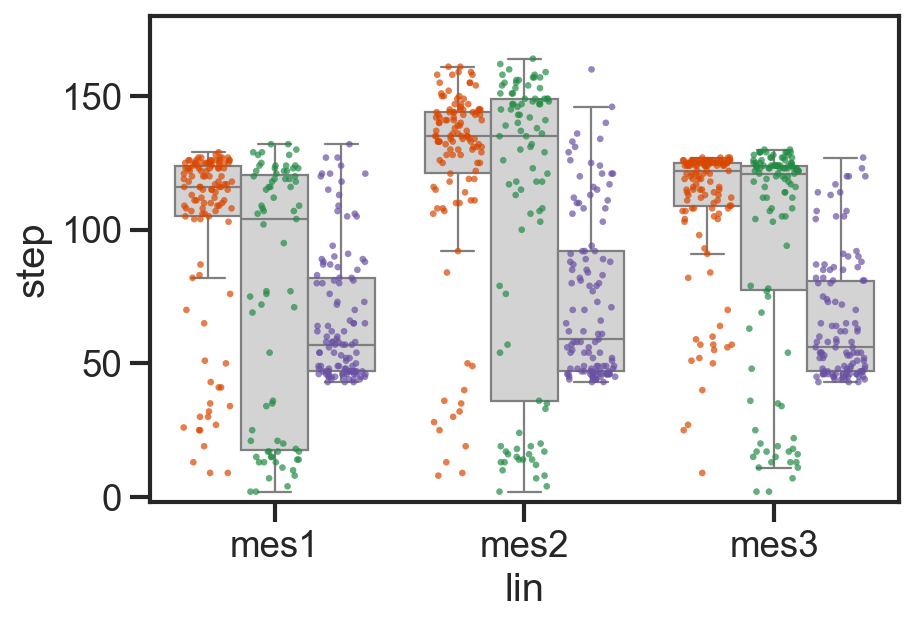

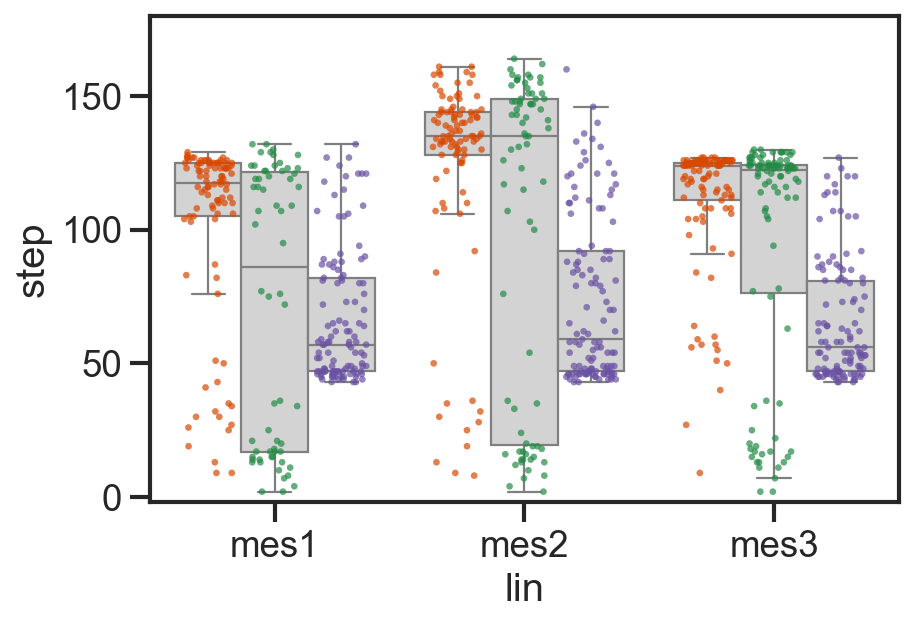

In [80]:
fig,ax = plt.subplots(figsize = (6,4))
sns.boxplot(data = meso_changes_f,ax=ax,
              x = 'lin', order = ['mes1','mes2','mes3'],fliersize = False,
              y = 'step', palette = ['lightgrey','lightgrey','lightgrey'],# [Orange,Purple],
              hue = 'layer', #palette = ['red','blue'],
              dodge = True)
sns.stripplot(data = meso_changes_f,ax=ax,
              x = 'lin', order = ['mes1','mes2','mes3'],
              y = 'step', palette = [Orange,Green,Purple], size = 3, alpha = 0.7, jitter = 0.3,
              hue = 'layer', #palette = ['red','blue'],
              dodge = True)
plt.legend([],frameon = False)
plt.ylim([-2,180])
plt.savefig('figs/20250417_mes_steps_changing_per_layer_unfiltered.png', bbox_inches = 'tight')
plt.show()

fig,ax = plt.subplots(figsize = (6,4))
sns.boxplot(data = meso_changes_f[meso_changes_f['gene'].isin(meso_K27RNA_changing)],ax=ax,
              x = 'lin', order = ['mes1','mes2','mes3'],fliersize = False,
              y = 'step', palette = ['lightgrey','lightgrey','lightgrey'],# [Orange,Purple],
              hue = 'layer', #palette = ['red','blue'],
              dodge = True)
sns.stripplot(data = meso_changes_f[meso_changes_f['gene'].isin(meso_K27RNA_changing)],ax=ax,
              x = 'lin', order = ['mes1','mes2','mes3'],
              y = 'step', palette = [Orange,Green,Purple], size = 3, alpha = 0.7, jitter = 0.3,
              hue = 'layer', #palette = ['red','blue'],
              dodge = True)
plt.legend([],frameon = False)
plt.ylim([-2,180])
plt.savefig('figs/20250417_mes_steps_changing_per_layer_K27RNA.png', bbox_inches = 'tight')
plt.show()

fig,ax = plt.subplots(figsize = (6,4))
sns.boxplot(data = meso_changes_f[meso_changes_f['gene'].isin(meso_K4RNA_changing)],ax=ax,
              x = 'lin', order = ['mes1','mes2','mes3'],fliersize = False,
              y = 'step', palette = ['lightgrey','lightgrey','lightgrey'],# [Orange,Purple],
              hue = 'layer', #palette = ['red','blue'],
              dodge = True)
sns.stripplot(data = meso_changes_f[meso_changes_f['gene'].isin(meso_K4RNA_changing)],ax=ax,
              x = 'lin', order = ['mes1','mes2','mes3'],
              y = 'step', palette = [Orange,Green,Purple], size = 3, alpha = 0.7, jitter = 0.3,
              hue = 'layer', #palette = ['red','blue'],
              dodge = True)
plt.legend([],frameon = False)
plt.ylim([-2,180])
plt.savefig('figs/20250417_mes_steps_changing_per_layer_K4RNA.png', bbox_inches = 'tight')
plt.show()

fig,ax = plt.subplots(figsize = (6,4))
sns.boxplot(data = meso_changes_f[meso_changes_f['gene'].isin(meso_allchanging)],ax=ax,
              x = 'lin', order = ['mes1','mes2','mes3'],fliersize = False,
              y = 'step', palette = ['lightgrey','lightgrey','lightgrey'],# [Orange,Purple],
              hue = 'layer', #palette = ['red','blue'],
              dodge = True)
sns.stripplot(data = meso_changes_f[meso_changes_f['gene'].isin(meso_allchanging)],ax=ax,
              x = 'lin', order = ['mes1','mes2','mes3'],
              y = 'step', palette = [Orange,Green,Purple], size = 3, alpha = 0.7, jitter = 0.3,
              hue = 'layer', #palette = ['red','blue'],
              dodge = True)
plt.legend([],frameon = False)
plt.ylim([-2,180])
plt.savefig('figs/20250417_mes_steps_changing_per_layer_all_changing.png', bbox_inches = 'tight')
plt.show()

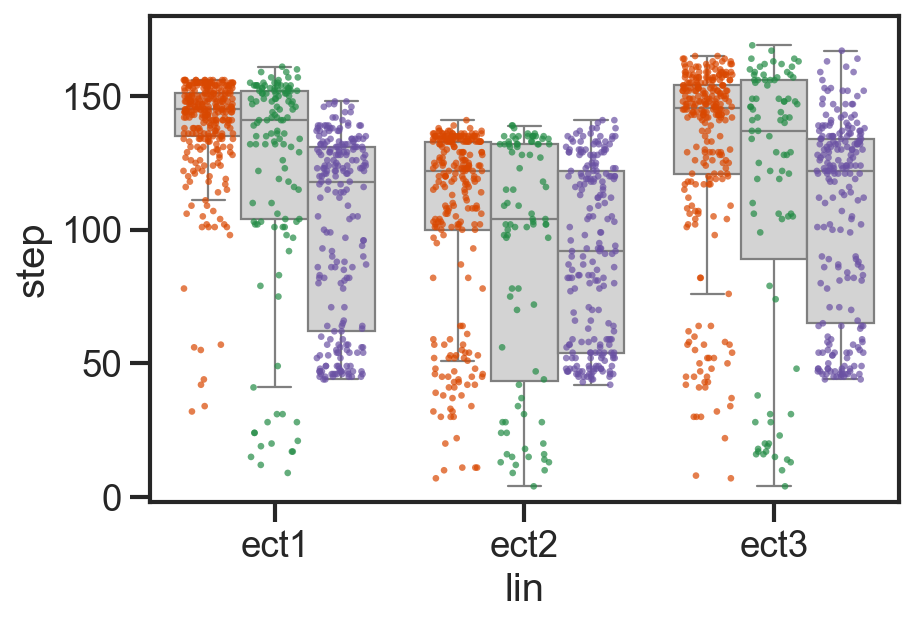

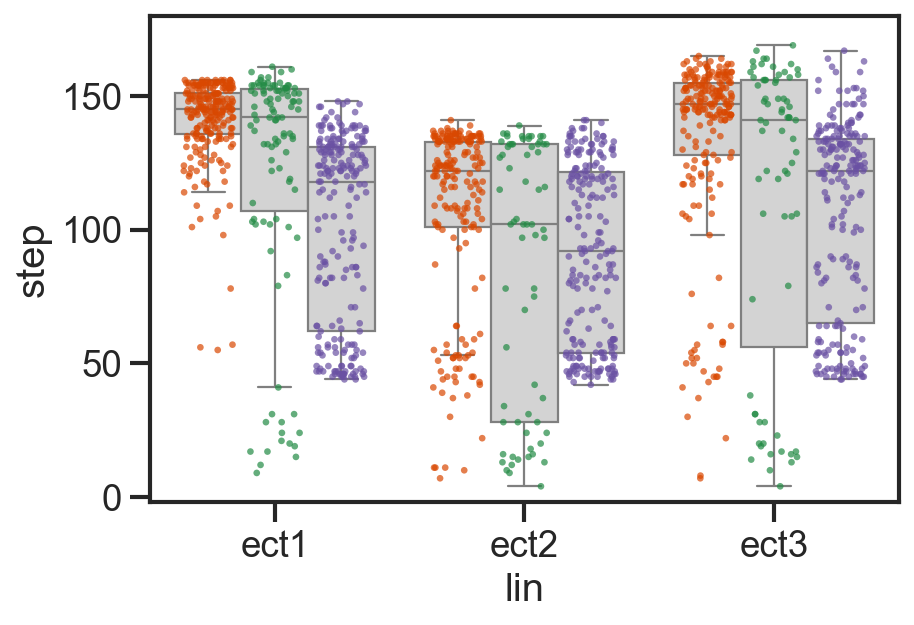

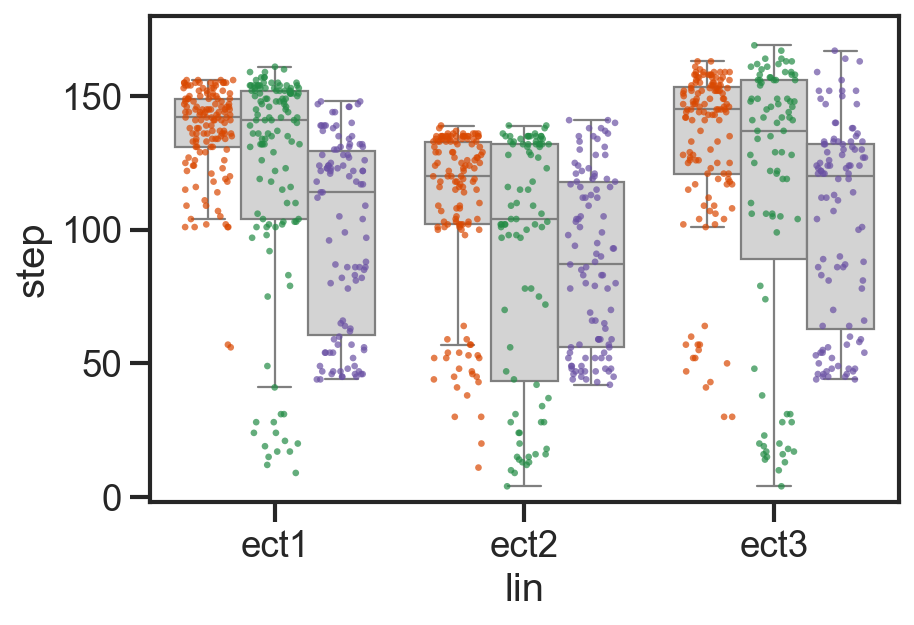

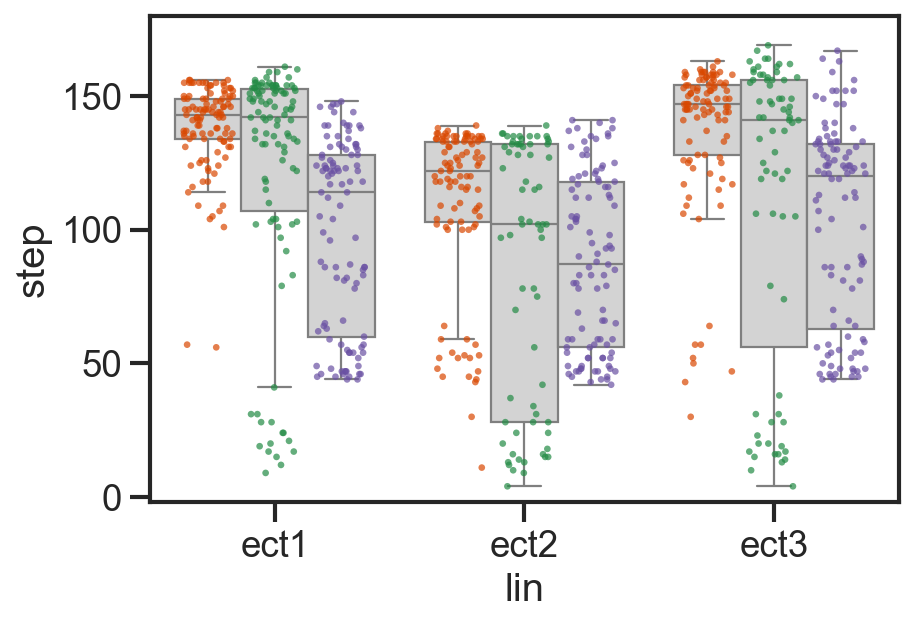

In [81]:
fig,ax = plt.subplots(figsize = (6,4))
sns.boxplot(data = ecto_changes_f,ax=ax,
              x = 'lin', order = ['ect1','ect2','ect3'],fliersize = False,
              y = 'step', palette = ['lightgrey','lightgrey','lightgrey'],# [Orange,Purple],
              hue = 'layer', #palette = ['red','blue'],
              dodge = True)
sns.stripplot(data = ecto_changes_f,ax=ax,
              x = 'lin', order = ['ect1','ect2','ect3'],
              y = 'step', palette = [Orange,Green,Purple], size = 3, alpha = 0.7, jitter = 0.3,
              hue = 'layer', #palette = ['red','blue'],
              dodge = True)
plt.legend([],frameon = False)
plt.ylim([-2,180])
plt.savefig('figs/20250417_ect_steps_changing_per_layer_unfiltered.png', bbox_inches = 'tight')
plt.show()

fig,ax = plt.subplots(figsize = (6,4))
sns.boxplot(data = ecto_changes_f[ecto_changes_f['gene'].isin(ecto_K27RNA_changing)],ax=ax,
              x = 'lin', order = ['ect1','ect2','ect3'],fliersize = False,
              y = 'step', palette = ['lightgrey','lightgrey','lightgrey'],# [Orange,Purple],
              hue = 'layer', #palette = ['red','blue'],
              dodge = True)
sns.stripplot(data = ecto_changes_f[ecto_changes_f['gene'].isin(ecto_K27RNA_changing)],ax=ax,
              x = 'lin', order = ['ect1','ect2','ect3'],
              y = 'step', palette = [Orange,Green,Purple], size = 3, alpha = 0.7, jitter = 0.3,
              hue = 'layer', #palette = ['red','blue'],
              dodge = True)
plt.legend([],frameon = False)
plt.ylim([-2,180])
plt.savefig('figs/20250417_ect_steps_changing_per_layer_K27RNA.png', bbox_inches = 'tight')
plt.show()

fig,ax = plt.subplots(figsize = (6,4))
sns.boxplot(data = ecto_changes_f[ecto_changes_f['gene'].isin(ecto_K4RNA_changing)],ax=ax,
              x = 'lin', order = ['ect1','ect2','ect3'],fliersize = False,
              y = 'step', palette = ['lightgrey','lightgrey','lightgrey'],# [Orange,Purple],
              hue = 'layer', #palette = ['red','blue'],
              dodge = True)
sns.stripplot(data = ecto_changes_f[ecto_changes_f['gene'].isin(ecto_K4RNA_changing)],ax=ax,
              x = 'lin', order = ['ect1','ect2','ect3'],
              y = 'step', palette = [Orange,Green,Purple], size = 3, alpha = 0.7, jitter = 0.3,
              hue = 'layer', #palette = ['red','blue'],
              dodge = True)
plt.legend([],frameon = False)
plt.ylim([-2,180])
plt.savefig('figs/20250417_ect_steps_changing_per_layer_K4RNA.png', bbox_inches = 'tight')
plt.show()

fig,ax = plt.subplots(figsize = (6,4))
sns.boxplot(data = ecto_changes_f[ecto_changes_f['gene'].isin(ecto_allchanging)],ax=ax,
              x = 'lin', order = ['ect1','ect2','ect3'],fliersize = False,
              y = 'step', palette = ['lightgrey','lightgrey','lightgrey'],# [Orange,Purple],
              hue = 'layer', #palette = ['red','blue'],
              dodge = True)
sns.stripplot(data = ecto_changes_f[ecto_changes_f['gene'].isin(ecto_allchanging)],ax=ax,
              x = 'lin', order = ['ect1','ect2','ect3'],
              y = 'step', palette = [Orange,Green,Purple], size = 3, alpha = 0.7, jitter = 0.3,
              hue = 'layer', #palette = ['red','blue'],
              dodge = True)
plt.legend([],frameon = False)
plt.ylim([-2,180])
plt.savefig('figs/20250417_ect_steps_changing_per_layer_all_changing.png', bbox_inches = 'tight')
plt.show()

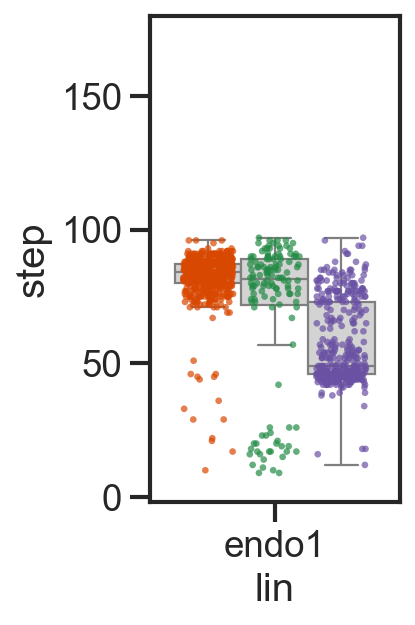

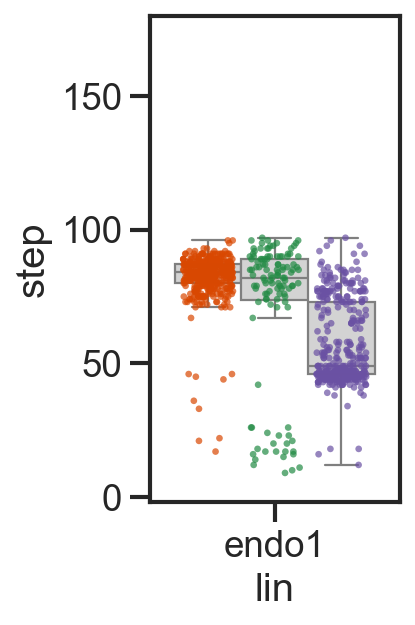

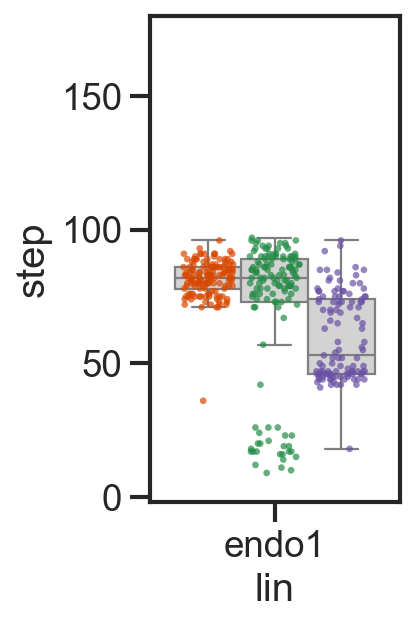

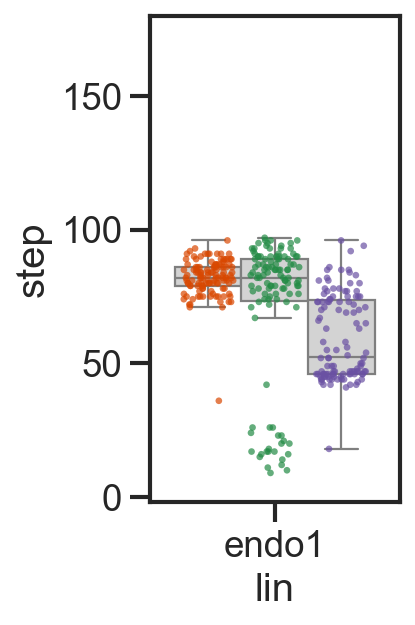

In [82]:
fig,ax = plt.subplots(figsize = (2,4))
sns.boxplot(data = endo_changes_f,ax=ax,
              x = 'lin', order = ['endo1'],fliersize = False,
              y = 'step', palette = ['lightgrey','lightgrey','lightgrey'],# [Orange,Purple],
              hue = 'layer', #palette = ['red','blue'],
              dodge = True)
sns.stripplot(data = endo_changes_f,ax=ax,
              x = 'lin', order = ['endo1'],
              y = 'step', palette = [Orange,Green,Purple], size = 3, alpha = 0.7, jitter = 0.3,
              hue = 'layer', #palette = ['red','blue'],
              dodge = True)
plt.legend([],frameon = False)
plt.ylim([-2,180])
plt.savefig('figs/20250417_end_steps_changing_per_layer_unfiltered.png', bbox_inches = 'tight')
plt.show()

fig,ax = plt.subplots(figsize = (2,4))
sns.boxplot(data = endo_changes_f[endo_changes_f['gene'].isin(endo_K27RNA_changing)],ax=ax,
              x = 'lin', order = ['endo1'],fliersize = False,
              y = 'step', palette = ['lightgrey','lightgrey','lightgrey'],# [Orange,Purple],
              hue = 'layer', #palette = ['red','blue'],
              dodge = True)
sns.stripplot(data = endo_changes_f[endo_changes_f['gene'].isin(endo_K27RNA_changing)],ax=ax,
              x = 'lin', order = ['endo1'],
              y = 'step', palette = [Orange,Green,Purple], size = 3, alpha = 0.7, jitter = 0.3,
              hue = 'layer', #palette = ['red','blue'],
              dodge = True)
plt.legend([],frameon = False)
plt.ylim([-2,180])
plt.savefig('figs/20250417_end_steps_changing_per_layer_K27RNA.png', bbox_inches = 'tight')
plt.show()

fig,ax = plt.subplots(figsize = (2,4))
sns.boxplot(data = endo_changes_f[endo_changes_f['gene'].isin(endo_K4RNA_changing)],ax=ax,
              x = 'lin', order = ['endo1'],fliersize = False,
              y = 'step', palette = ['lightgrey','lightgrey','lightgrey'],# [Orange,Purple],
              hue = 'layer', #palette = ['red','blue'],
              dodge = True)
sns.stripplot(data = endo_changes_f[endo_changes_f['gene'].isin(endo_K4RNA_changing)],ax=ax,
              x = 'lin', order = ['endo1'],
              y = 'step', palette = [Orange,Green,Purple], size = 3, alpha = 0.7, jitter = 0.3,
              hue = 'layer', #palette = ['red','blue'],
              dodge = True)
plt.legend([],frameon = False)
plt.ylim([-2,180])
plt.savefig('figs/20250417_end_steps_changing_per_layer_K4RNA.png', bbox_inches = 'tight')
plt.show()

fig,ax = plt.subplots(figsize = (2,4))
sns.boxplot(data = endo_changes_f[endo_changes_f['gene'].isin(endo_allchanging)],ax=ax,
              x = 'lin', order = ['endo1'],fliersize = False,
              y = 'step', palette = ['lightgrey','lightgrey','lightgrey'],# [Orange,Purple],
              hue = 'layer', #palette = ['red','blue'],
              dodge = True)
sns.stripplot(data = endo_changes_f[endo_changes_f['gene'].isin(endo_allchanging)],ax=ax,
              x = 'lin', order = ['endo1'],
              y = 'step', palette = [Orange,Green,Purple], size = 3, alpha = 0.7, jitter = 0.3,
              hue = 'layer', #palette = ['red','blue'],
              dodge = True)
plt.legend([],frameon = False)
plt.ylim([-2,180])
plt.savefig('figs/20250417_end_steps_changing_per_layer_all_changing.png', bbox_inches = 'tight')
plt.show()

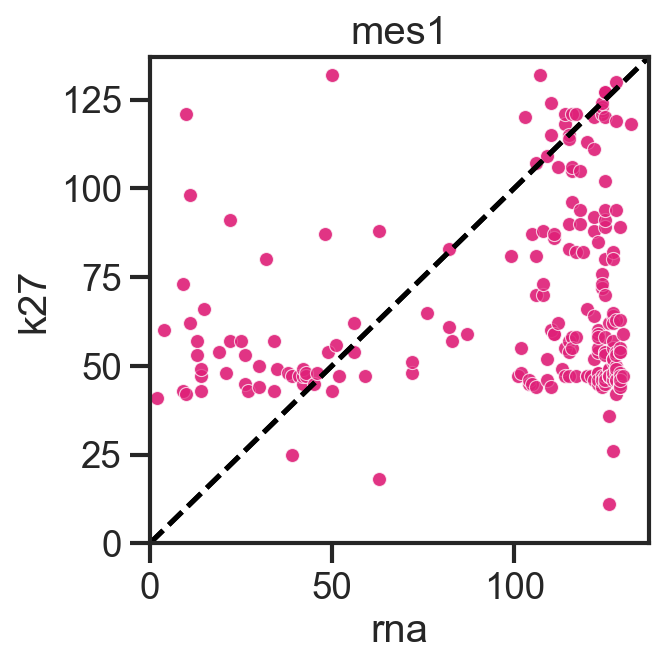

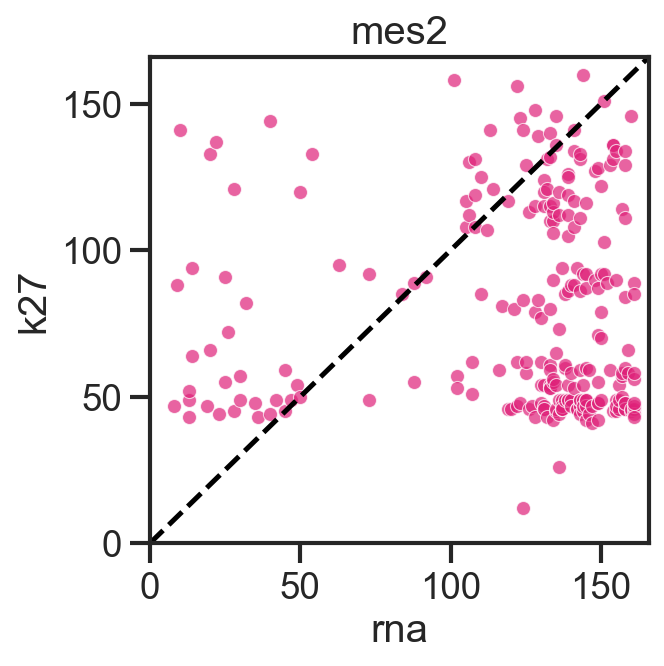

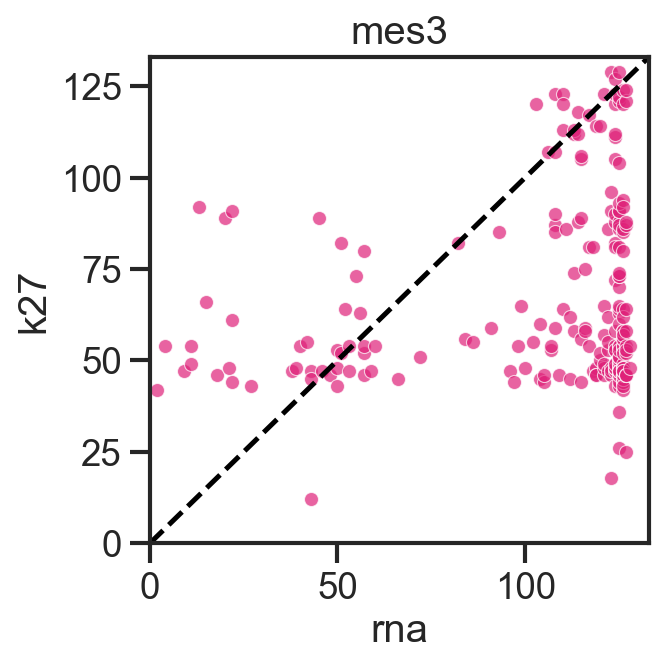

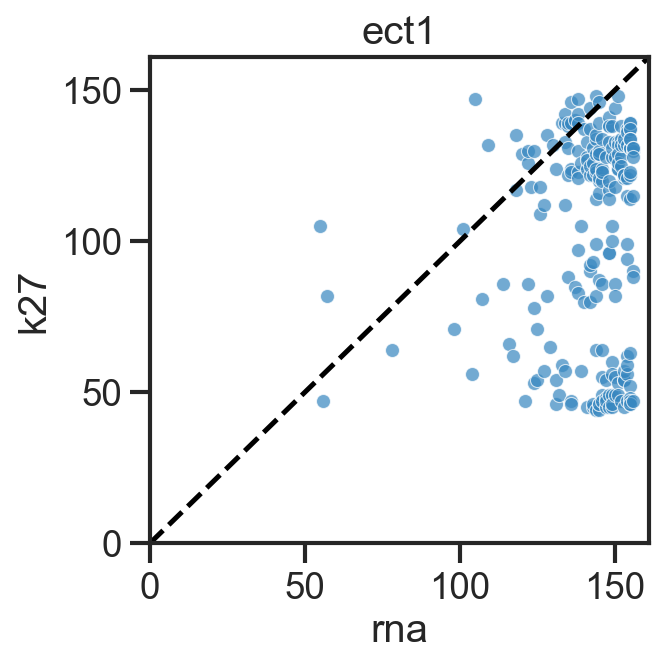

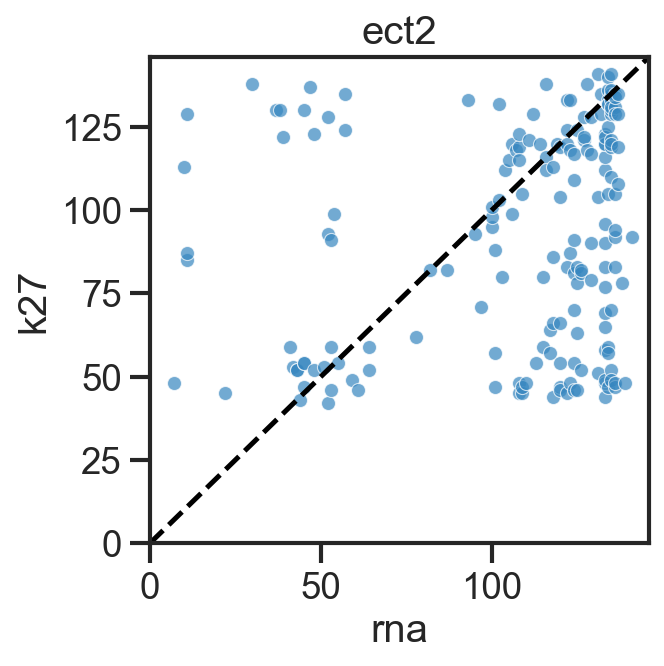

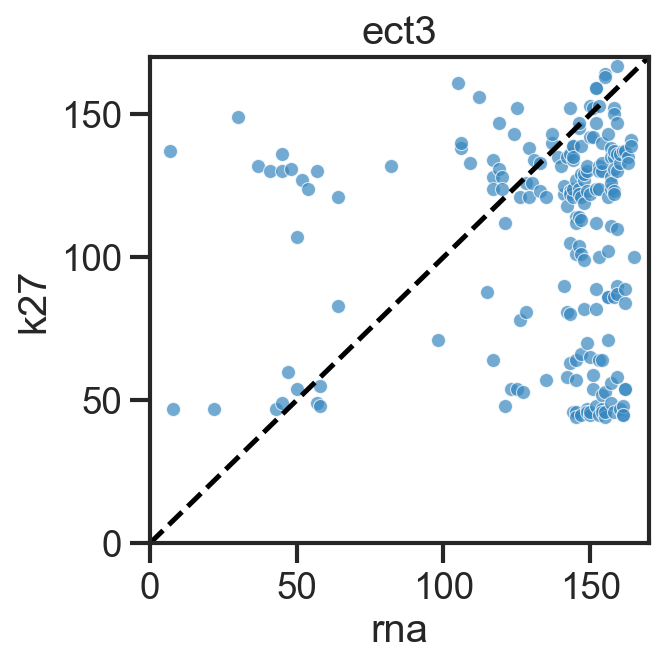

In [162]:
plotRNAvsK27(meso_changes_f,'mes1',col = 'Mesoderm',keep = 'first')# save = 'figs/scatter_rna_vs_k27_ect1.png')
plotRNAvsK27(meso_changes_f,'mes2',col = 'Mesoderm',keep = 'first')# save = 'figs/scatter_rna_vs_k27_ect1.png')
plotRNAvsK27(meso_changes_f,'mes3',col = 'Mesoderm',keep = 'first')# save = 'figs/scatter_rna_vs_k27_ect1.png')
ecto_changes_f = ecto_changes_f.reset_index()
plotRNAvsK27(ecto_changes_f,'ect1',col = 'Ectoderm',keep = 'first')# save = 'figs/scatter_rna_vs_k27_ect1.png')
plotRNAvsK27(ecto_changes_f,'ect2',col = 'Ectoderm',keep = 'first')# save = 'figs/scatter_rna_vs_k27_ect1.png')
plotRNAvsK27(ecto_changes_f,'ect3',col = 'Ectoderm',keep = 'first')# save = 'figs/scatter_rna_vs_k27_ect1.png')

# calculate difference between RNA and K27

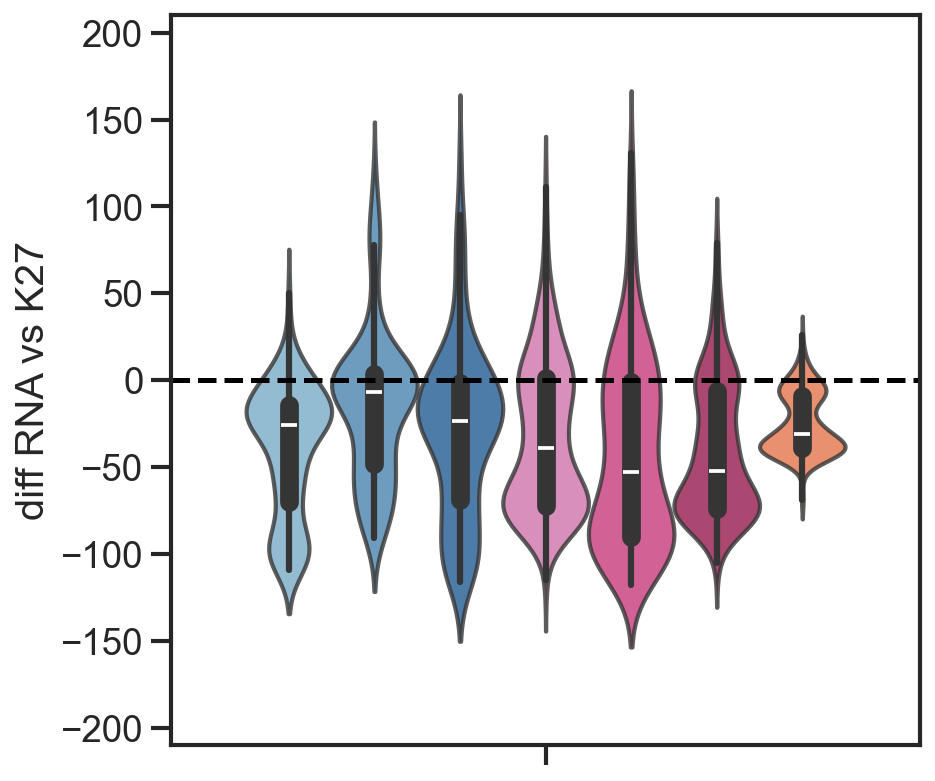

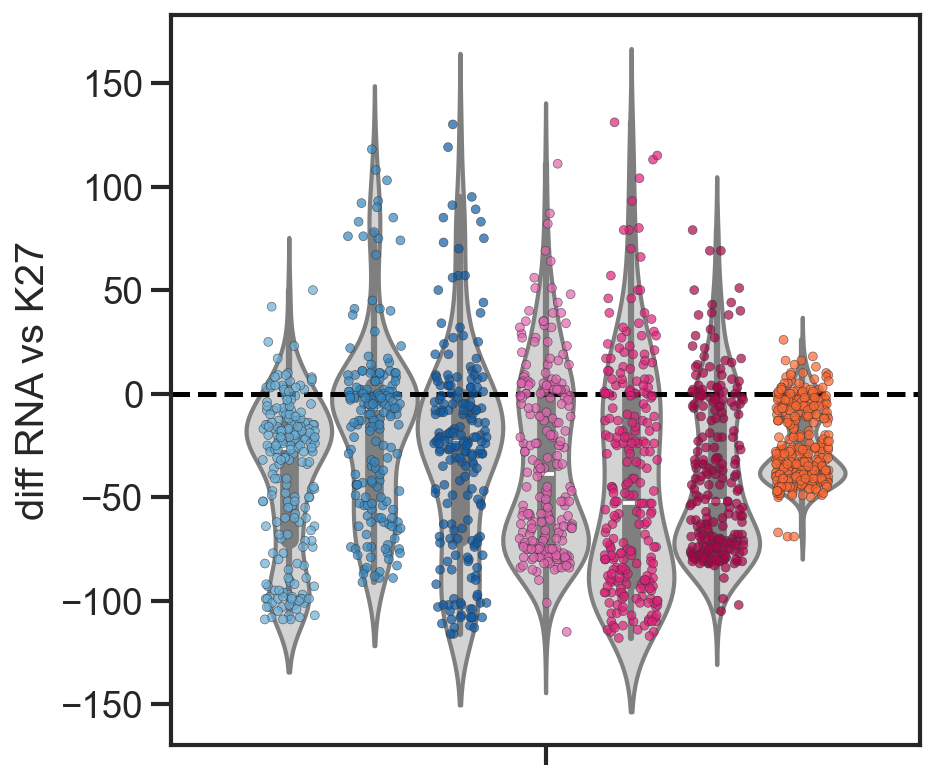

In [164]:
d1 = calculateDiff(ecto_changes_f,'ect1',keep = 'first')
d2 = calculateDiff(ecto_changes_f,'ect2',keep = 'first')
d3 = calculateDiff(ecto_changes_f,'ect3',keep = 'first')

d4 = calculateDiff(meso_changes_f,'mes1',keep = 'first')
d5 = calculateDiff(meso_changes_f,'mes2',keep = 'first')
d6 = calculateDiff(meso_changes_f,'mes3',keep = 'first')

d7 = calculateDiff(endo_changes_f,'endo1',keep = 'first')

pal = ['#6AAED6', '#3787C0', '#105BA4', '#DF64AF', '#DF2179', '#A90649', '#FC6832',]
fig,ax = plt.subplots(figsize = (6,6))
sns.violinplot(data = pd.concat([d1,d2,d3,d4,d5,d6,d7]),ax=ax,
        y = 'diff', #fliersize = False,
               palette = pal,alpha = 0.8,
            hue = 'lin')
plt.legend([],frameon=False)
plt.axhline(0, linestyle = 'dashed', c = 'black')
plt.ylabel('diff RNA vs K27')
plt.ylim([-210, 210])
plt.savefig('figs/20250415_violin_deltaRNAvsK27_stdev_unfiltered.png',bbox_inches = 'tight')
plt.show()

fig,ax = plt.subplots(figsize = (6,6))
sns.violinplot(data = pd.concat([d1,d2,d3,d4,d5,d6,d7]),ax=ax,
        y = 'diff', #fliersize = False,
               palette = ['lightgrey'],
            hue = 'lin')
sns.stripplot(data = pd.concat([d1,d2,d3,d4,d5,d6,d7]),ax=ax,
        y = 'diff',palette = pal,dodge = True, size = 4, alpha = 0.7, jitter = 0.25,linewidth = 0.3,
            hue = 'lin')
plt.legend([],frameon=False)
plt.axhline(0, linestyle = 'dashed', c = 'black')
plt.ylabel('diff RNA vs K27')
#plt.savefig('figs/20250306_barplot_deltaRNAvsK27_fix.png',bbox_inches = 'tight')
plt.show()

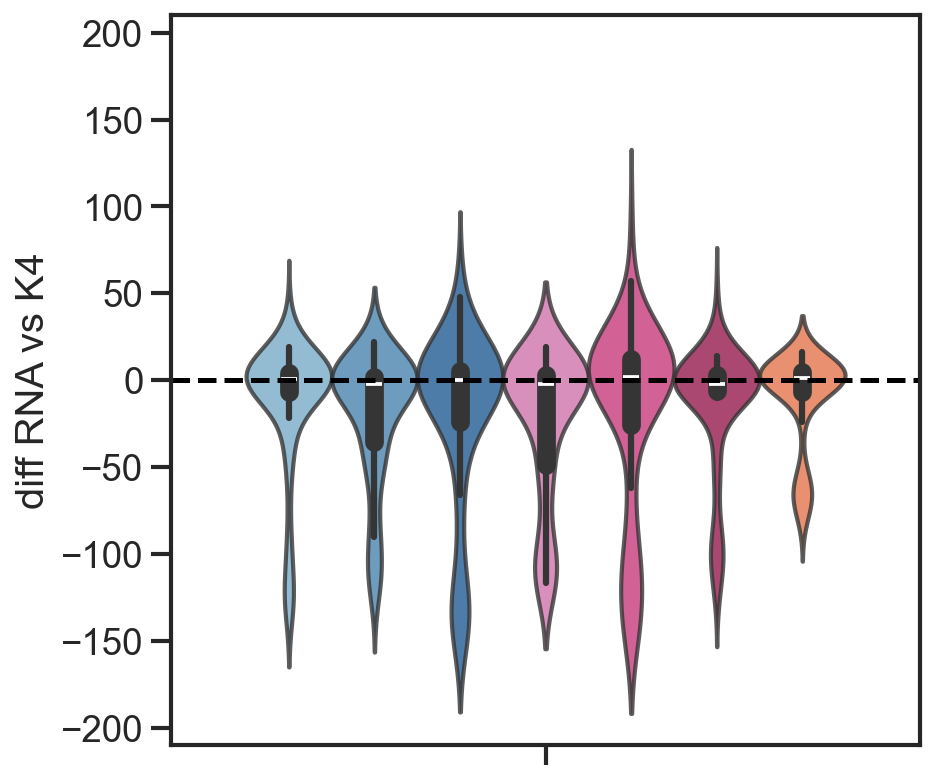

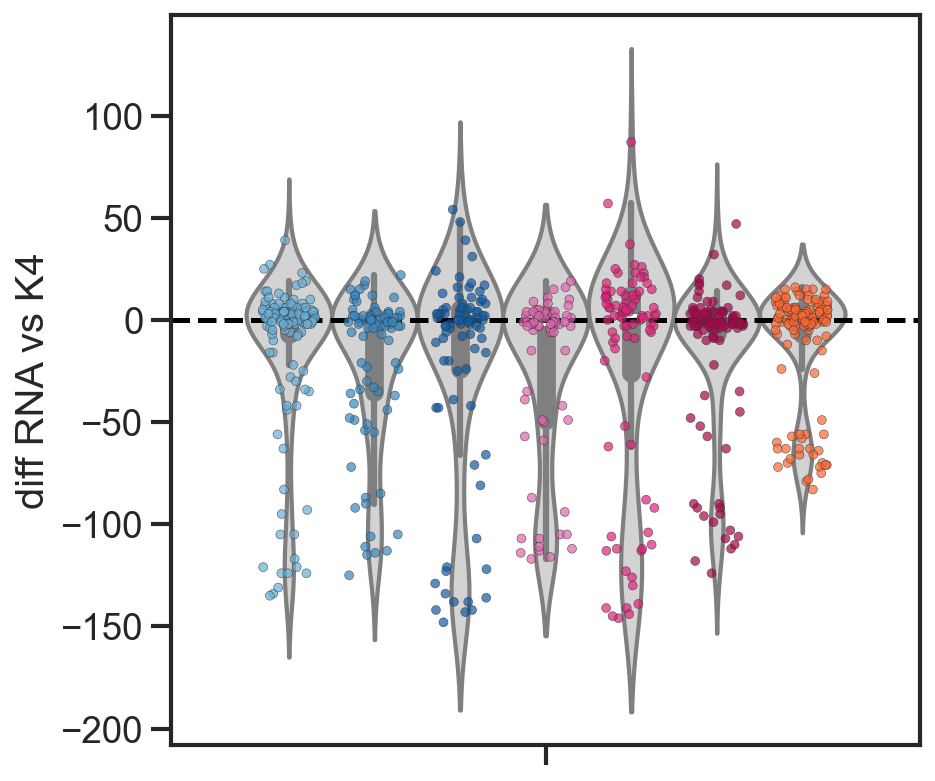

In [165]:
d1 = calculateDiff(ecto_changes_f,'ect1',keep = 'first',mark = 'K4')
d2 = calculateDiff(ecto_changes_f,'ect2',keep = 'first',mark = 'K4')
d3 = calculateDiff(ecto_changes_f,'ect3',keep = 'first',mark = 'K4')

d4 = calculateDiff(meso_changes_f,'mes1',keep = 'first',mark = 'K4')
d5 = calculateDiff(meso_changes_f,'mes2',keep = 'first',mark = 'K4')
d6 = calculateDiff(meso_changes_f,'mes3',keep = 'first',mark = 'K4')

d7 = calculateDiff(endo_changes_f,'endo1',keep = 'first',mark = 'K4')

pal = ['#6AAED6', '#3787C0', '#105BA4', '#DF64AF', '#DF2179', '#A90649', '#FC6832',]
fig,ax = plt.subplots(figsize = (6,6))
sns.violinplot(data = pd.concat([d1,d2,d3,d4,d5,d6,d7]),ax=ax,
        y = 'diff', #fliersize = False,
               palette = pal,alpha = 0.8,
            hue = 'lin')
plt.legend([],frameon=False)
plt.axhline(0, linestyle = 'dashed', c = 'black')
plt.ylabel('diff RNA vs K4')
plt.ylim([-210, 210])
plt.savefig('figs/20250415_violinplot_deltaRNAvsK4_stdev_unfiltered.png',bbox_inches = 'tight')
plt.show()

fig,ax = plt.subplots(figsize = (6,6))
sns.violinplot(data = pd.concat([d1,d2,d3,d4,d5,d6,d7]),ax=ax,
        y = 'diff', #fliersize = False,
               palette = ['lightgrey'],
            hue = 'lin')
sns.stripplot(data = pd.concat([d1,d2,d3,d4,d5,d6,d7]),ax=ax,
        y = 'diff',palette = pal,dodge = True, size = 4, alpha = 0.7, jitter = 0.25,linewidth = 0.3,
            hue = 'lin')
plt.legend([],frameon=False)
plt.axhline(0, linestyle = 'dashed', c = 'black')
plt.ylabel('diff RNA vs K4')
#plt.savefig('figs/20250306_barplot_deltaRNAvsK27_fix.png',bbox_inches = 'tight')
plt.show()

In [166]:
endo_K27RNA_changing = list(pd.DataFrame(endo_changes_f[endo_changes_f['layer'] != 'K4'][['gene','lin']].value_counts()[endo_changes_f[endo_changes_f['layer'] != 'K4'][['gene','lin']].value_counts() == 2]).reset_index()['gene'].unique())
meso_K27RNA_changing = list(pd.DataFrame(meso_changes_f[meso_changes_f['layer'] != 'K4'][['gene','lin']].value_counts()[meso_changes_f[meso_changes_f['layer'] != 'K4'][['gene','lin']].value_counts() == 2]).reset_index()['gene'].unique())
ecto_K27RNA_changing = list(pd.DataFrame(ecto_changes_f[ecto_changes_f['layer'] != 'K4'][['gene','lin']].value_counts()[ecto_changes_f[ecto_changes_f['layer'] != 'K4'][['gene','lin']].value_counts() == 2]).reset_index()['gene'].unique())

endo_K4RNA_changing = list(pd.DataFrame(endo_changes_f[endo_changes_f['layer'] != 'K27'][['gene','lin']].value_counts()[endo_changes_f[endo_changes_f['layer'] != 'K27'][['gene','lin']].value_counts() == 2]).reset_index()['gene'].unique())
meso_K4RNA_changing = list(pd.DataFrame(meso_changes_f[meso_changes_f['layer'] != 'K27'][['gene','lin']].value_counts()[meso_changes_f[meso_changes_f['layer'] != 'K27'][['gene','lin']].value_counts() == 2]).reset_index()['gene'].unique())
ecto_K4RNA_changing = list(pd.DataFrame(ecto_changes_f[ecto_changes_f['layer'] != 'K27'][['gene','lin']].value_counts()[ecto_changes_f[ecto_changes_f['layer'] != 'K27'][['gene','lin']].value_counts() == 2]).reset_index()['gene'].unique())

endo_allchanging = list(pd.DataFrame(endo_changes_f[['gene','lin']].value_counts()[endo_changes_f[['gene','lin']].value_counts() == 3]).reset_index()['gene'].unique())
meso_allchanging = list(pd.DataFrame(meso_changes_f[['gene','lin']].value_counts()[meso_changes_f[['gene','lin']].value_counts() == 3]).reset_index()['gene'].unique())
ecto_allchanging = list(pd.DataFrame(ecto_changes_f[['gene','lin']].value_counts()[ecto_changes_f[['gene','lin']].value_counts() == 3]).reset_index()['gene'].unique())

print(len(endo_K27RNA_changing), len(meso_K27RNA_changing),len(ecto_K27RNA_changing))

427 300 227


In [169]:
def plotChanges(df,lin,keep='first',save = None, xaxis = 'step'):
    df['dup'] = df['lin_layer'] + '_' + df['gene']
    df_unique = df[~df['dup'].duplicated(keep = keep)]
    fig,ax = plt.subplots(3,1, figsize = (6,4),gridspec_kw = {'wspace':0, 'hspace':0.05})
    sns.histplot(df_unique[(df_unique['lin'] == lin) & (df_unique['layer'] == 'RNA')][xaxis],
                ax=ax[0], color= Orange, binwidth=2.5)
    sns.histplot(df_unique[(df_unique['lin'] == lin) & (df_unique['layer'] == 'K4')][xaxis],
                ax=ax[1], color= Green,binwidth = 2.5)
    sns.histplot(df_unique[(df_unique['lin'] == lin) & (df_unique['layer'] == 'K27')][xaxis],
                ax=ax[2], color= Purple, binwidth=2.5)
    dict1 = {}
    for x in df['lin_layer'].unique():
        dict1[x] = df[df['lin_layer'] == x]['step'].max()
    for x in range(3):
        ax[x].set_xlim([0,dict1[lin+'_RNA']+5])
        ax[x].set_xticks([])
        ax[x].set_xlabel('')
        ax[x].set_yticks([])
        ax[x].set_ylabel('')
        ax[x].set_ylim([0,80])
    ax[1].set_ylim([0,40])
    if save != None:
        plt.savefig(save,bbox_inches='tight')
    plt.show()

def plotChangesRT(df,lin,keep='first',save = None, xaxis = 'RT'):
    df['dup'] = df['lin_layer'] + '_' + df['gene']
    df_unique = df[~df['dup'].duplicated(keep = keep)]
    fig,ax = plt.subplots(3,1, figsize = (5,3),gridspec_kw = {'wspace':0, 'hspace':0.05})
    sns.histplot(df_unique[(df_unique['lin'] == lin) & (df_unique['layer'] == 'RNA')][xaxis],
                ax=ax[0], color= Orange, binwidth=2.5)
    sns.histplot(df_unique[(df_unique['lin'] == lin) & (df_unique['layer'] == 'K4')][xaxis],
                ax=ax[1], color= Green,binwidth = 2.5)
    sns.histplot(df_unique[(df_unique['lin'] == lin) & (df_unique['layer'] == 'K27')][xaxis],
                ax=ax[2], color= Purple, binwidth=2.5)
    #dict1 = {}
    #for x in df['lin_layer'].unique():
    #    dict1[x] = df[df['lin_layer'] == x]['step'].max()
    for x in range(3):
     #   ax[x].set_xlim([0,dict1[lin+'_RNA']+5])
        ax[x].set_xticks([])
        ax[x].set_xlabel('')
        ax[x].set_yticks([])
        ax[x].set_ylabel('')
    ax[2].set_ylim([0,300])
    ax[1].set_ylim([0,100])
    ax[0].set_ylim([0,250])
    if save != None:
        plt.savefig(save,bbox_inches='tight')
    plt.show()



In [71]:
def plotline(count_table, lineage = 'ect1',genelist = ['Onecut2'], val = 'sm',xval = 'step', save = None,figsize = (4,4)):

    df = pd.pivot_table(count_table[count_table['lin'] == lineage][[val, 'layer',xval]], columns = 'gene', index = ['layer',xval],values = val)
    fig,ax=plt.subplots(figsize=(figsize))
    

    df_rna = df.loc['RNA']
    df_k4 = df.loc['K4']
    df_k27 = df.loc['K27']

    df_rna = df_rna[genelist]
    df_k4 = df_k4[genelist]
    df_k27 = df_k27[genelist]
    
    # order = scipy.cluster.hierarchy.leaves_list(scipy.cluster.hierarchy.linkage(df.T.fillna(0)))
    df_k271 = pd.DataFrame(df_k27.unstack()).rename(columns={0:'vals'})
    df_k271['mod'] = 'k27'
    df_k41 = pd.DataFrame(df_k4.unstack()).rename(columns={0:'vals'})
    df_k41['mod'] = 'k4'
    df_rna1 = pd.DataFrame(df_rna.unstack()).rename(columns={0:'vals'})
    df_rna1['mod'] = 'rna'
        
    sns.lineplot(data = pd.concat([df_k271, df_k41, df_rna1]), ax=ax,
                    x = xval,
                    y = 'vals',
                    hue = 'mod',
                     hue_order = ['rna','k4','k27'],
                    palette = [Orange, Green, Purple])
    

    ax.legend([],frameon=False)
    
    ax.set_xticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')   
    
    #ax[0].set_xlim(df_k271.index.get_level_values(xval).unique()[[0,-1]])
    ax.set_ylim([0,1])
    ax.set_yticks([0,0.2,0.4,0.6,0.8,1.0])
    if save != None:
        plt.savefig(save , bbox_inches='tight')
    plt.show()
    plt.close()

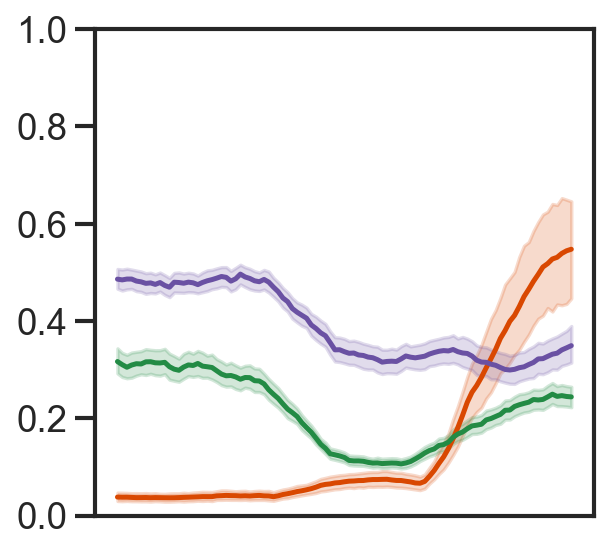

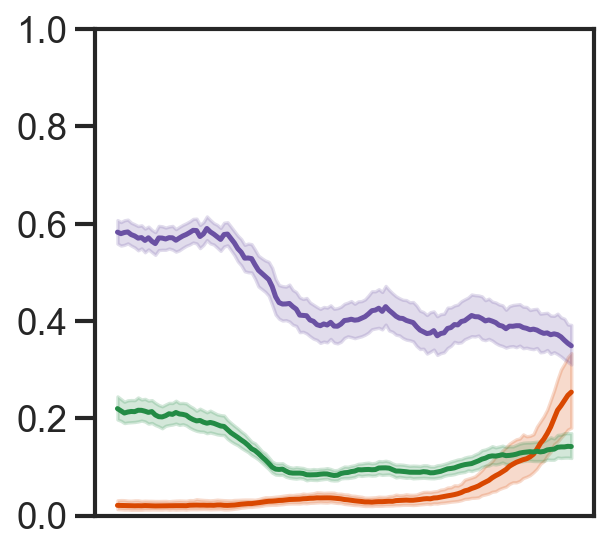

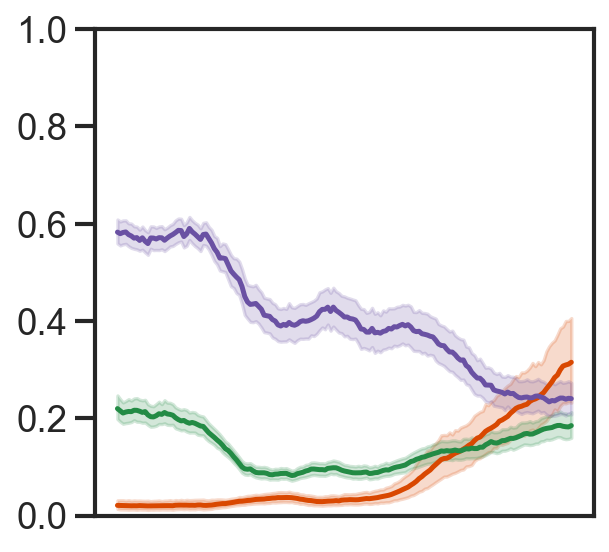

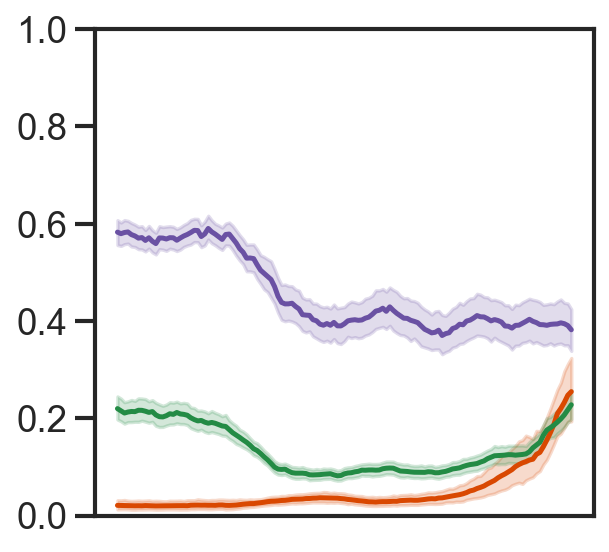

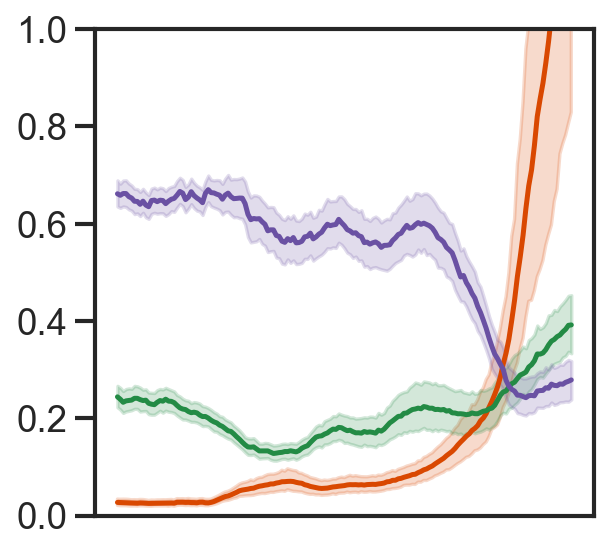

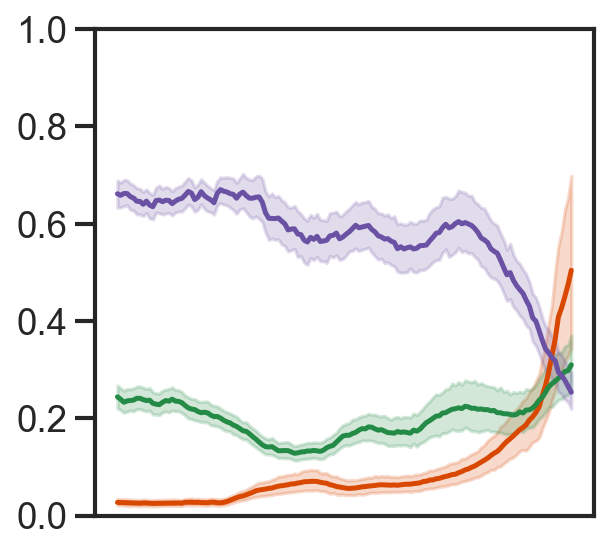

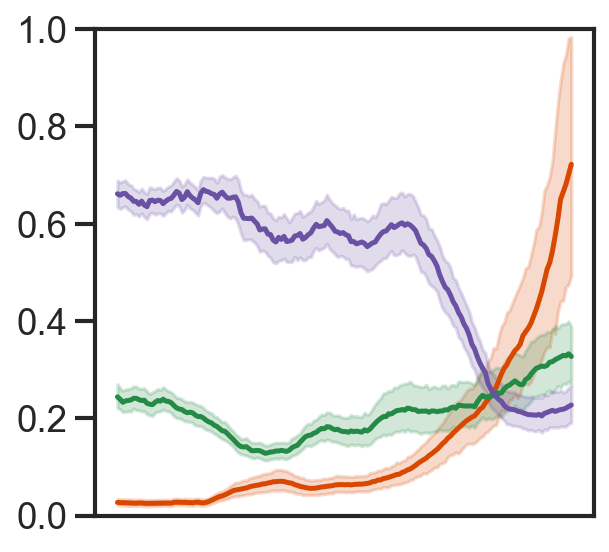

In [72]:
plotline(to_plot1, lineage = 'endo1', genelist = to_plot1.index.unique(), val = 'p_98', xval = 'step', save = 'figs/20250416_endogenes_endo1_step.png')
plotline(to_plot2, lineage = 'mes1', genelist = to_plot2.index.unique(), val = 'p_98', xval = 'step', save = 'figs/20250416_mesogenes_mes1_step.png')
plotline(to_plot2, lineage = 'mes2', genelist = to_plot2.index.unique(), val = 'p_98', xval = 'step', save = 'figs/20250416_mesogenes_mes2_step.png')
plotline(to_plot2, lineage = 'mes3', genelist = to_plot2.index.unique(), val = 'p_98', xval = 'step', save = 'figs/20250416_mesogenes_mes3_step.png')
plotline(to_plot3, lineage = 'ect1', genelist = to_plot3.index.unique(), val = 'p_98', xval = 'step', save = 'figs/20250416_ectogenes_ect1_step.png')
plotline(to_plot3, lineage = 'ect2', genelist = to_plot3.index.unique(), val = 'p_98', xval = 'step', save = 'figs/20250416_ectogenes_ect2_step.png')
plotline(to_plot3, lineage = 'ect3', genelist = to_plot3.index.unique(), val = 'p_98', xval = 'step', save = 'figs/20250416_ectogenes_ect3_step.png')


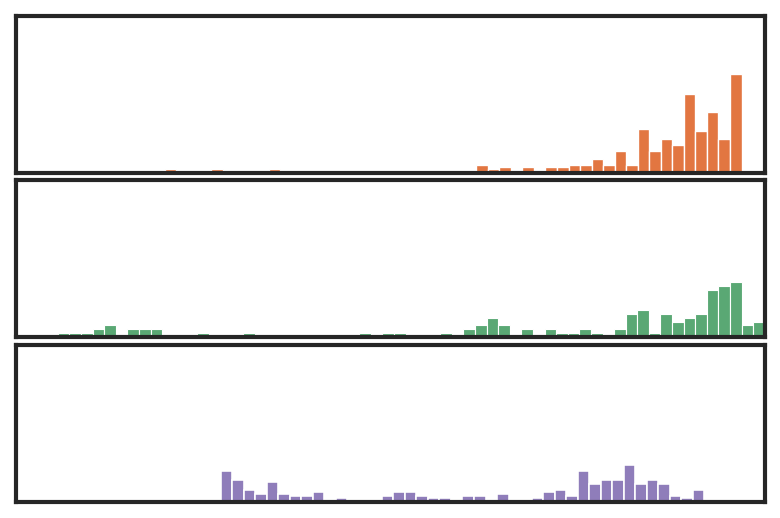

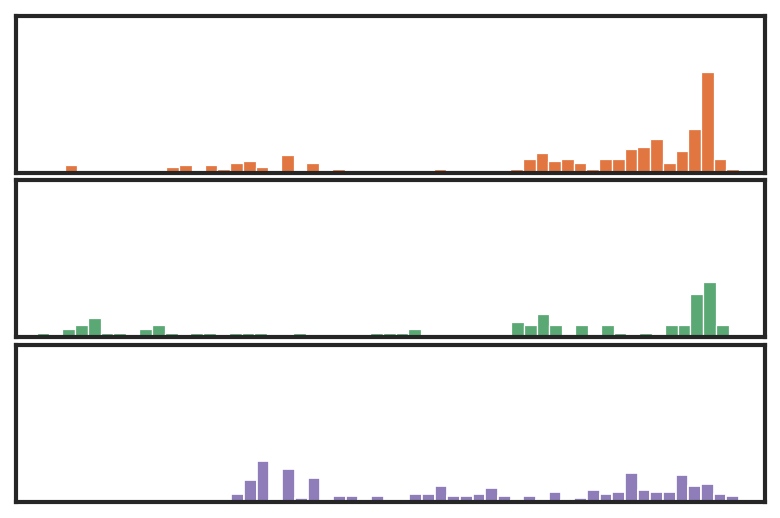

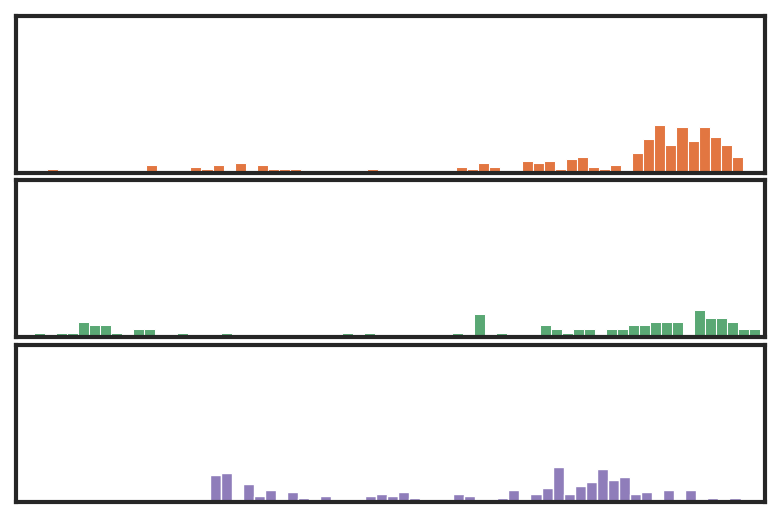

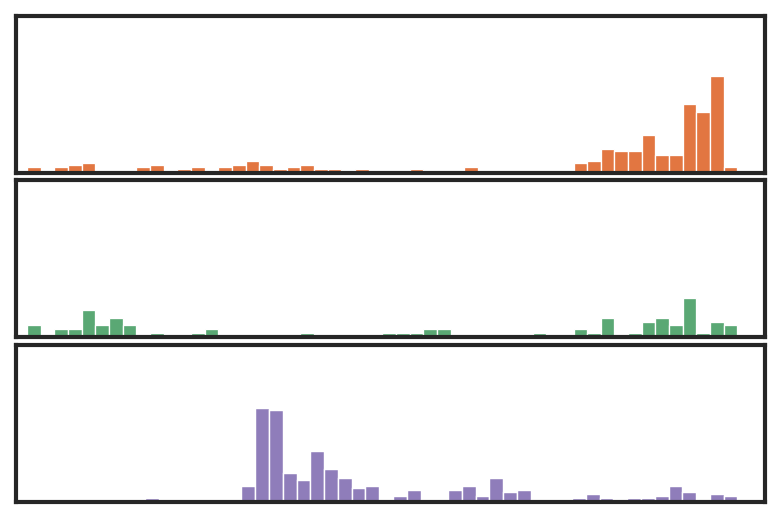

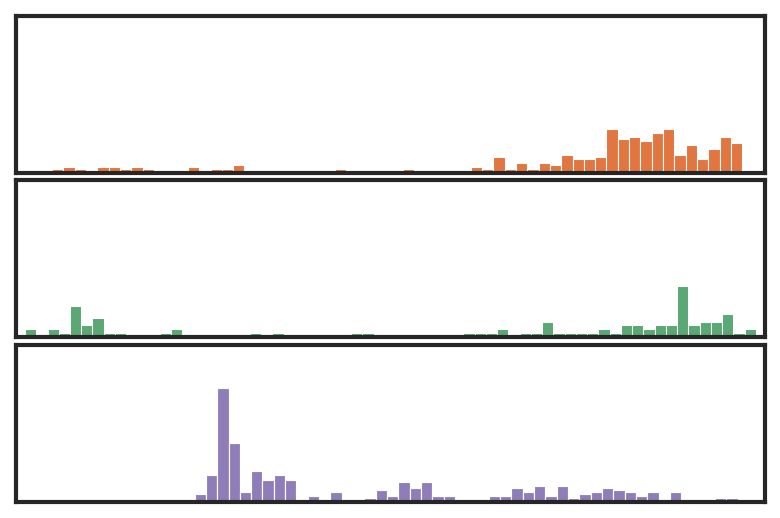

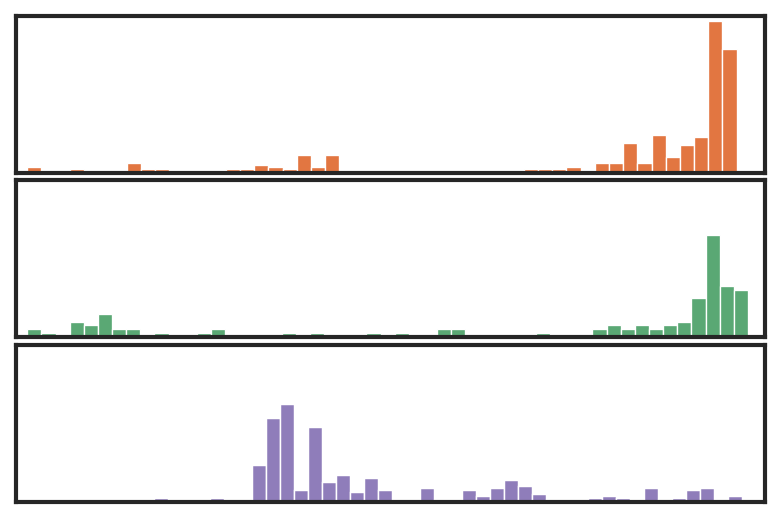

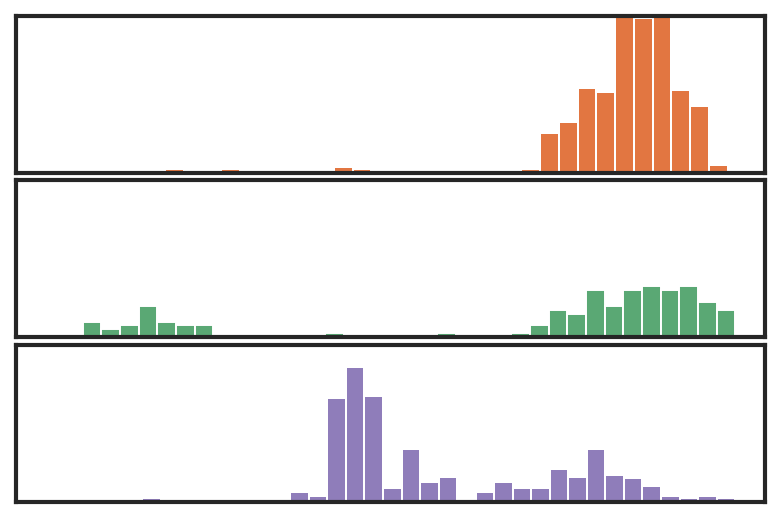

In [170]:
plotChanges(ecto_changes_f,'ect1',save = 'figs/20250417_histplot_changes_stdev_ect1.png')
plotChanges(ecto_changes_f,'ect2',save = 'figs/20250417_histplot_changes_stdev_ect2.png')
plotChanges(ecto_changes_f,'ect3',save = 'figs/20250417_histplot_changes_stdev_ect3.png')

plotChanges(meso_changes_f,'mes1',save = 'figs/20250417_histplot_changes_stdev_mes1.png')
plotChanges(meso_changes_f,'mes2',save = 'figs/20250417_histplot_changes_stdev_mes2.png')
plotChanges(meso_changes_f,'mes3',save = 'figs/20250417_histplot_changes_stdev_mes3.png')

plotChanges(endo_changes_f,'endo1',save = 'figs/20250417_histplot_changes_stdev_end1.png')

0
547


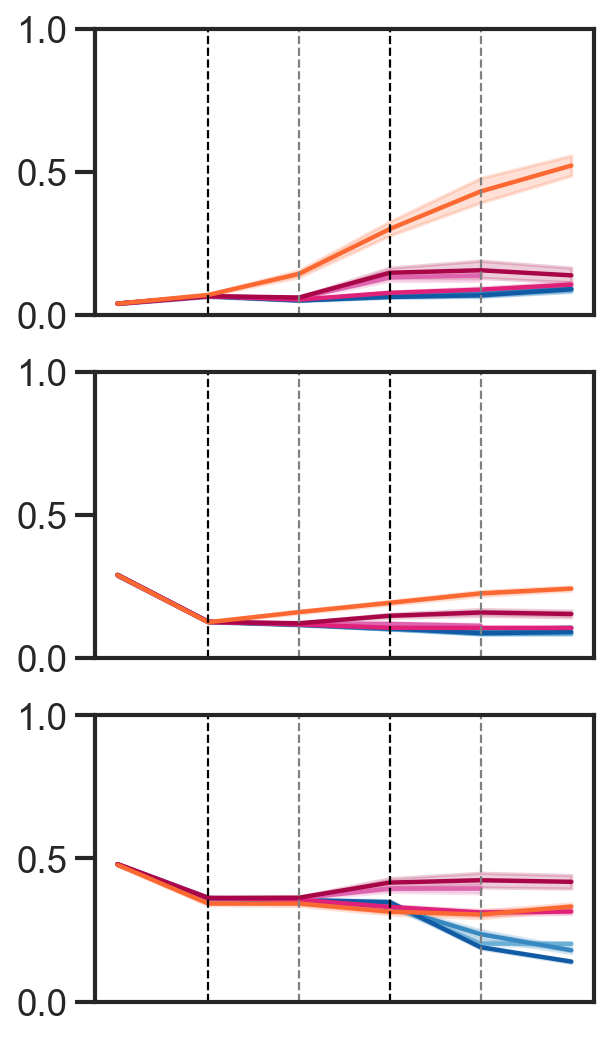

1
365


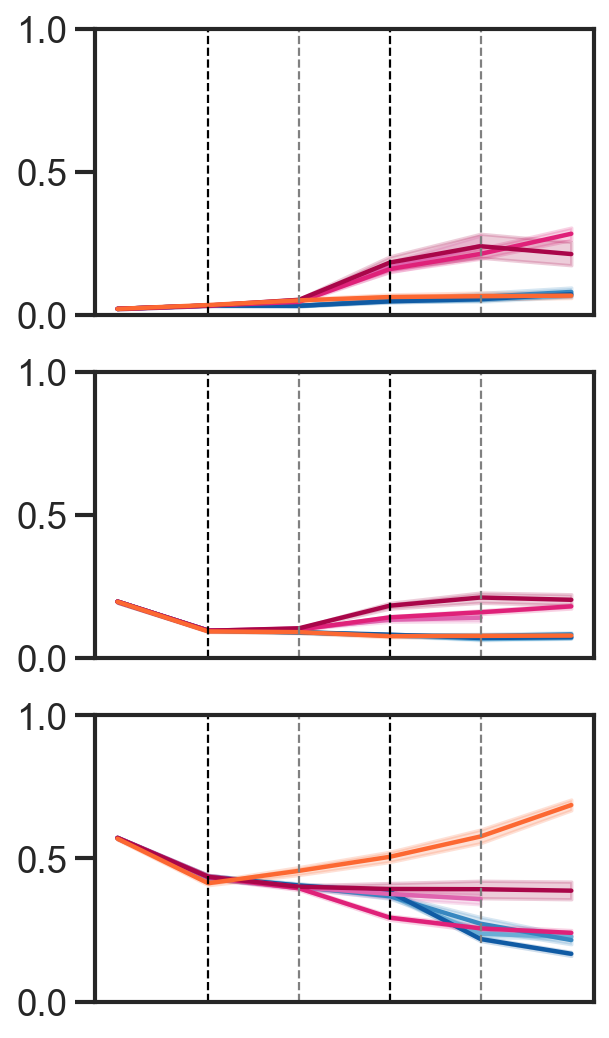

2
290


FileNotFoundError: [Errno 2] No such file or directory: '/Users/mbloten1/Library/CloudStorage/OneDrive-UniversitédeLausanne/Documents/jupyter_default/2025/tchic_figures/fig6/figs/20250416_lineplot_RT_ecto.png'

In [74]:
xval = 'RT'
yval = 'p_98'
hue = 'lin'
hue_order = ['ect1','ect2','ect3',
            'mes1','mes2','mes3',
            'endo1',]
palette = ['#6AAED6', '#3787C0', '#105BA4', '#DF64AF', '#DF2179', '#A90649', '#FC6832',]

mod = ['RNA', 'K4','K27']
plots = [endo,meso,ecto]
order = ['endo','meso','ecto']

for num, item in enumerate(plots):
    print(num)
    to_plot = ct_normalised.loc[item[item['Gene'].isin(ct_normalised.index)]['Gene']]
    print(len(to_plot.index.unique()))
    fig,ax = plt.subplots(3,1, figsize = (4,8))
    for x in range(3):
        sns.lineplot(data = to_plot[to_plot['layer'] == mod[x]], linewidth = 2,
                     ax=ax[x],
                     x = xval, y = yval,hue = hue,hue_order = hue_order, palette = palette)
    
        ax[x].set_title('')

    for axes in ax:
        axes.set_xlabel('')
        axes.set_ylabel('')
        axes.set_ylim([0,1])
        axes.set_xticks([])
        axes.legend([],frameon=False) 
        axes.axvline('Gastd3',linestyle = 'dashed',c = 'black',linewidth = 1)
        axes.axvline('Gastd5',linestyle = 'dashed',c = 'black',linewidth = 1)
        axes.axvline('Gastd4',linestyle = 'dashed',c = 'grey',linewidth = 1)
        axes.axvline('Gastd6',linestyle = 'dashed',c = 'grey',linewidth = 1)
    plt.savefig('figs/20250416_lineplot_RT_' +str(order[num]) + '.png', bbox_inches='tight')
    plt.show()